# Global E-Commerce Customer Purchase Prediction

https://www.kaggle.com/competitions/global-e-commerce-customer-purchase-prediction/data

1. Data preprocessing

*   customers
*   geo
*   marketing_campaigns
*   transactions
*   sessions
2. aggegrate
*  merge session + geo + campaigns
*  transaction
3.  LSTM
4. Table หลัก ใช้สำหรับ tree-based model
5. feature ทั้งหมดที่มี
6. EDA
7. split data 80-10-10
8. Catboost



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Data

In [ ]:
train = pd.read_csv('train.csv')
customers = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')
sessions = pd.read_csv('sessions.csv')
campaigns = pd.read_csv('marketing_campaigns.csv')
geo = pd.read_csv('geo_data.csv')

Overview of data

In [ ]:
print(f'train        : {train.shape}')
print(f'customers    : {customers.shape}')
print(f'transactions : {transactions.shape}')
print(f'sessions     : {sessions.shape}')
print(f'campaigns    : {campaigns.shape}')
print(f'geo          : {geo.shape}')

train        : (160000, 2)
customers    : (200000, 17)
transactions : (500000, 11)
sessions     : (2000000, 11)
campaigns    : (200, 6)
geo          : (100, 5)


In [ ]:
for name, df in [('train', train),
                 ('customers', customers),
                 ('transactions', transactions),
                 ('sessions', sessions),
                 ('campaigns', campaigns),
                 ('geo', geo)]:
    print(f'\n{"="*55}')
    print(f'{name}  shape={df.shape}')
    print(f'  columns : {list(df.columns)}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'  missing :\n{missing.to_string()}')
    else:
        print(f'  missing : ไม่มี')


train  shape=(160000, 2)
  columns : ['customer_id', 'target']
  missing : ไม่มี

customers  shape=(200000, 17)
  columns : ['customer_id', 'age', 'country_code', 'region', 'signup_date', 'loyalty_score', 'email_open_rate', 'discount_usage_rate', 'avg_review_score', 'referral_code', 'customer_tier', 'credit_limit', 'noise_customer_0', 'noise_customer_1', 'noise_customer_2', 'noise_customer_3', 'noise_customer_4']
  missing :
email_open_rate    22746

transactions  shape=(500000, 11)
  columns : ['transaction_id', 'customer_id', 'transaction_timestamp', 'order_value', 'items_count', 'payment_method', 'discount_applied', 'shipping_speed', 'high_value_flag', 'noise_trans_0', 'noise_trans_1']
  missing : ไม่มี

sessions  shape=(2000000, 11)
  columns : ['session_id', 'customer_id', 'session_timestamp', 'session_duration', 'pages_viewed', 'cart_additions', 'bounce_flag', 'traffic_source', 'device_type', 'campaign_id', 'geo_ip_region']
  missing :
pages_viewed    100000

campaigns  shape=(2

# Data Preprocessing

## Left Join with Train

In [ ]:
train_cust_ids = set(train['customer_id'])

# filter ด้วย customer_id
customers    = customers[customers['customer_id'].isin(train_cust_ids)]
transactions = transactions[transactions['customer_id'].isin(train_cust_ids)]
sessions     = sessions[sessions['customer_id'].isin(train_cust_ids)]

# filter ด้วย key ที่ถูกต้องตาม schema
train_campaign_ids  = set(sessions['campaign_id'].dropna())
train_geo_regions   = set(sessions['geo_ip_region'].dropna())

campaigns = campaigns[campaigns['campaign_id'].isin(train_campaign_ids)]
geo       = geo[geo['geo_ip_region'].isin(train_geo_regions)]

In [ ]:
print(f'customers    : {customers.shape}')
print(f'transactions : {transactions.shape}')
print(f'sessions     : {sessions.shape}')
print(f'campaigns    : {campaigns.shape}')
print(f'geo          : {geo.shape}')

customers    : (160000, 17)
transactions : (400227, 11)
sessions     : (1599831, 11)
campaigns    : (200, 6)
geo          : (100, 5)


## Customers

In [ ]:
customers.head(10)

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,referral_code,customer_tier,credit_limit,noise_customer_0,noise_customer_1,noise_customer_2,noise_customer_3,noise_customer_4
0,0,73,usa,region_50,2022-08-02,0.244,0.660207,0.238170,4.837508,REF_904704,Bronze,"$10,966",-0.348931,0.744826,0.043670,-1.712753,2.179607
1,1,47,U.S.,region_3,2023-06-14,0.196,0.257952,0.332332,4.447899,REF_183413,Silver,"$14,189",-0.330203,-0.415826,-0.514494,0.584026,0.832590
2,2,67,USA,region_54,2024-01-06,0.326,0.157587,0.002592,3.641375,REF_535074,Platinum,"$15,043",-0.608613,-0.668642,0.637331,0.629255,0.257232
3,3,21,USA,region_82,2023-12-07,0.116,0.234343,0.246847,3.935681,REF_754240,Silver,"$8,484",-1.168023,-1.159494,0.665311,-2.725670,0.808534
4,4,35,IN,region_33,2023-10-16,0.371,0.230297,0.127043,3.966327,REF_794359,Silver,"$13,128",0.253426,0.556899,1.331644,1.097365,0.457113
6,6,unknown,uk,region_38,2022-09-21,0.216,0.205725,0.305972,3.384852,REF_335594,Platinum,"$14,246",0.014773,-0.559773,0.337430,-1.295362,0.137995
7,7,65,DE,region_20,2023-09-14,0.243,0.641041,0.445190,4.379374,REF_108215,Silver,"$14,030",0.045251,1.073539,-0.404309,0.772301,0.404186
8,8,18,USA,region_95,2022-04-08,0.257,0.331690,0.103732,4.394058,REF_730422,Platinum,"$3,057",1.171790,0.364354,0.323391,0.112844,-0.674482
9,9,70,FR,region_86,2023-09-29,0.538,0.225508,0.592174,3.187260,REF_426221,Platinum,"$10,576",-0.558025,-0.750810,0.317401,-0.521620,-0.042303
10,10,63,IN,region_58,2023-05-28,0.290,0.070463,0.178687,3.731187,REF_216586,Silver,"$17,160",0.055215,1.073932,0.034919,-0.435788,-0.720650


ดู dtype ของแต่ละคอลัมน์

In [ ]:
print(customers.dtypes)

customer_id              int64
age                     object
country_code            object
region                  object
signup_date             object
loyalty_score          float64
email_open_rate        float64
discount_usage_rate    float64
avg_review_score       float64
referral_code           object
customer_tier           object
credit_limit            object
noise_customer_0       float64
noise_customer_1       float64
noise_customer_2       float64
noise_customer_3       float64
noise_customer_4       float64
dtype: object


ดู Missing Values

In [ ]:
missing = customers.isnull().sum()
pct     = (missing / len(customers) * 100).round(2)

result = pd.DataFrame({'จำนวนที่หาย': missing, 'คิดเป็น %': pct})
print(result)

                     จำนวนที่หาย  คิดเป็น %
customer_id                    0       0.00
age                            0       0.00
country_code                   0       0.00
region                         0       0.00
signup_date                    0       0.00
loyalty_score                  0       0.00
email_open_rate            18220      11.39
discount_usage_rate            0       0.00
avg_review_score               0       0.00
referral_code                  0       0.00
customer_tier                  0       0.00
credit_limit                   0       0.00
noise_customer_0               0       0.00
noise_customer_1               0       0.00
noise_customer_2               0       0.00
noise_customer_3               0       0.00
noise_customer_4               0       0.00


ดู Unique Values ของแต่ละคอลัมน์

In [ ]:
for col in customers.columns:
    n = customers[col].nunique()
    if n <= 15:
        # ถ้าค่าไม่เยอะ แสดงทั้งหมด
        print(f'\n{col} ({n} unique):')
        print(sorted(customers[col].dropna().astype(str).unique()))
    else:
        # ถ้าค่าเยอะ แสดงแค่ตัวอย่าง 5 ค่า
        print(f'\n{col} ({n} unique): ตัวอย่าง → {list(customers[col].dropna().astype(str).unique()[:5])} ...')


customer_id (160000 unique): ตัวอย่าง → ['0', '1', '2', '3', '4'] ...

age (58 unique): ตัวอย่าง → ['73', '47', '67', '21', '35'] ...

country_code (10 unique):
['DE', 'FR', 'IN', 'U.S.', 'UK', 'US', 'USA', 'de', 'uk', 'usa']

region (100 unique): ตัวอย่าง → ['region_50', 'region_3', 'region_54', 'region_82', 'region_33'] ...

signup_date (800 unique): ตัวอย่าง → ['2022-08-02', '2023-06-14', '2024-01-06', '2023-12-07', '2023-10-16'] ...

loyalty_score (879 unique): ตัวอย่าง → ['0.244', '0.196', '0.326', '0.116', '0.371'] ...

email_open_rate (141780 unique): ตัวอย่าง → ['0.6602071312818953', '0.2579521435416791', '0.157587366835483', '0.2343429996803932', '0.2302973149647547'] ...

discount_usage_rate (160000 unique): ตัวอย่าง → ['0.238169641660012', '0.3323316386886913', '0.0025923669890838', '0.2468474254480079', '0.1270426376445762'] ...

avg_review_score (160000 unique): ตัวอย่าง → ['4.837507826904929', '4.447899201484501', '3.641374590037804', '3.935680730642191', '3.966327304975

### Drop noise columns

In [ ]:
noise_cols = [c for c in customers.columns if 'noise' in c.lower()]
customers.drop(columns=noise_cols, inplace=True)

print(f'dropped: {noise_cols}')
print(f'columns ที่เหลือ: {list(customers.columns)}')
print(f'shape: {customers.shape}')

dropped: ['noise_customer_0', 'noise_customer_1', 'noise_customer_2', 'noise_customer_3', 'noise_customer_4']
columns ที่เหลือ: ['customer_id', 'age', 'country_code', 'region', 'signup_date', 'loyalty_score', 'email_open_rate', 'discount_usage_rate', 'avg_review_score', 'referral_code', 'customer_tier', 'credit_limit']
shape: (160000, 12)


### age

In [ ]:
# ดูก่อนว่ามีค่าอะไรแปลกๆ นอกจาก 'unknown' บ้าง
print('ค่าที่ไม่ใช่ตัวเลขใน age:')
print(customers[pd.to_numeric(customers['age'], errors='coerce').isna()]['age'].value_counts())

ค่าที่ไม่ใช่ตัวเลขใน age:
age
unknown    8015
Name: count, dtype: int64


mean   : 45.95
median : 46.00
std    : 16.43
min    : 18.0
max    : 74.0


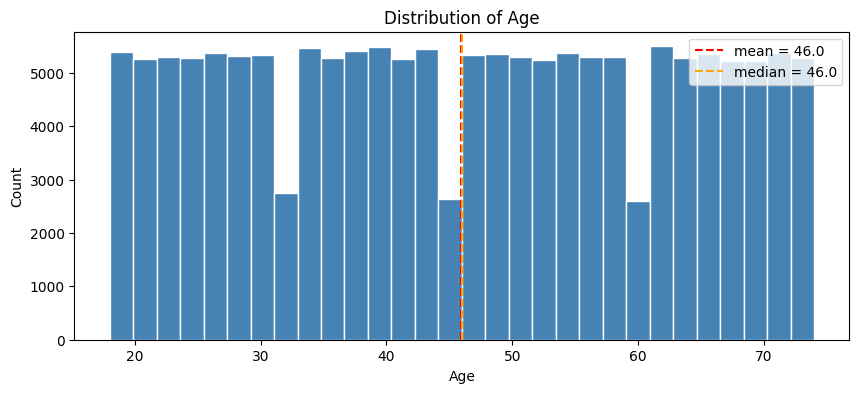

In [ ]:
age_numeric = pd.to_numeric(customers['age'], errors='coerce').dropna()

print(f'mean   : {age_numeric.mean():.2f}')
print(f'median : {age_numeric.median():.2f}')
print(f'std    : {age_numeric.std():.2f}')
print(f'min    : {age_numeric.min()}')
print(f'max    : {age_numeric.max()}')

plt.figure(figsize=(10, 4))
plt.hist(age_numeric, bins=30, color='steelblue', edgecolor='white')
plt.axvline(age_numeric.mean(),   color='red',    linestyle='--', label=f'mean = {age_numeric.mean():.1f}')
plt.axvline(age_numeric.median(), color='orange', linestyle='--', label=f'median = {age_numeric.median():.1f}')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

แปลง age + สร้าง age_imputed

In [ ]:
# แปลง unknown → NaN
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

# สร้าง column ใหม่ที่ impute ด้วย median
customers['age_imputed'] = customers['age'].fillna(customers['age'].median())

# ตรวจสอบ
print(f'age missing        : {customers["age"].isna().sum()}')
print(f'age_imputed missing: {customers["age_imputed"].isna().sum()}')
print(f'median ที่ใช้ impute : {customers["age"].median()}')

age missing        : 8015
age_imputed missing: 0
median ที่ใช้ impute : 46.0


In [ ]:
customers[['age','age_imputed']].head(10)

,age,age_imputed
0,73.0,73.0
1,47.0,47.0
2,67.0,67.0
3,21.0,21.0
4,35.0,35.0
6,NaN,46.0
7,65.0,65.0
8,18.0,18.0
9,70.0,70.0
10,63.0,63.0


### country_code

In [ ]:
print(customers['country_code'].value_counts())

country_code
usa     16248
UK      16135
USA     16130
uk      16070
U.S.    15959
de      15931
DE      15923
FR      15913
US      15863
IN      15828
Name: count, dtype: int64


Inconsistency format

In [ ]:
country_map = {
    'usa': 'USA', 'USA': 'USA', 'US': 'USA', 'U.S.': 'USA',
    'uk': 'UK',   'UK': 'UK',
    'de': 'DE',   'DE': 'DE',
    'FR': 'FR',
    'IN': 'IN'
}

customers['country_code'] = customers['country_code'].map(country_map)

print(customers['country_code'].value_counts())
print(f'\nmissing: {customers["country_code"].isna().sum()}')

country_code
USA    64200
UK     32205
DE     31854
FR     15913
IN     15828
Name: count, dtype: int64

missing: 0


### signup_date

In [ ]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')

print(customers['signup_date'].dtype)
print(f'missing: {customers["signup_date"].isna().sum()}')
print(f'วันแรกสุด : {customers["signup_date"].min()}')
print(f'วันล่าสุด : {customers["signup_date"].max()}')

datetime64[ns]
missing: 0
วันแรกสุด : 2022-01-01 00:00:00
วันล่าสุด : 2024-03-10 00:00:00


### email_open_rate

missing: 18220
missing %: 11.39%

mean   : 0.3337
median : 0.3143


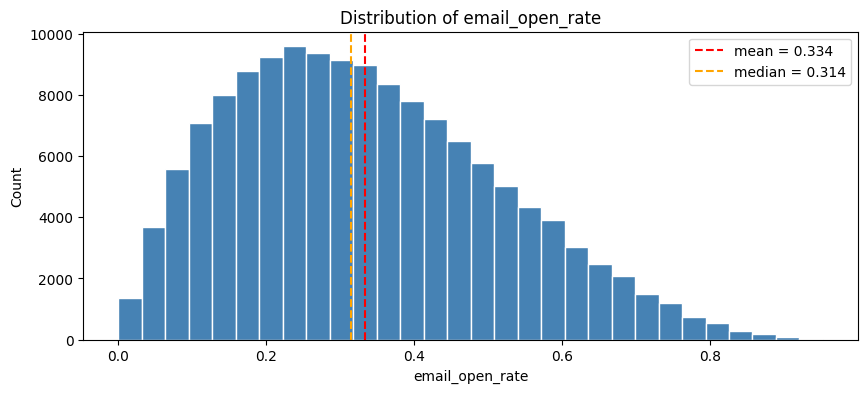

In [ ]:
print(f'missing: {customers["email_open_rate"].isna().sum()}')
print(f'missing %: {customers["email_open_rate"].isna().sum() / len(customers) * 100:.2f}%')

print(f'\nmean   : {customers["email_open_rate"].mean():.4f}')
print(f'median : {customers["email_open_rate"].median():.4f}')

plt.figure(figsize=(10, 4))
plt.hist(customers['email_open_rate'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.axvline(customers['email_open_rate'].mean(),   color='red',    linestyle='--', label=f'mean = {customers["email_open_rate"].mean():.3f}')
plt.axvline(customers['email_open_rate'].median(), color='orange', linestyle='--', label=f'median = {customers["email_open_rate"].median():.3f}')
plt.title('Distribution of email_open_rate')
plt.xlabel('email_open_rate')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
customers['email_open_rate_imputed'] = customers['email_open_rate'].fillna(customers['email_open_rate'].median())

print(f'email_open_rate missing         : {customers["email_open_rate"].isna().sum()}')
print(f'email_open_rate_imputed missing : {customers["email_open_rate_imputed"].isna().sum()}')
print(f'median ที่ใช้ impute : {customers["email_open_rate"].median():.4f}')

email_open_rate missing         : 18220
email_open_rate_imputed missing : 0
median ที่ใช้ impute : 0.3143


### referral_code

In [ ]:
print(f'missing: {customers["referral_code"].isna().sum()}')
print(f'missing %: {customers["referral_code"].isna().sum() / len(customers) * 100:.2f}%')

missing: 0
missing %: 0.00%


drop

In [ ]:
customers.drop(columns=['referral_code'], inplace=True)

print(f'columns ที่เหลือ: {list(customers.columns)}')

columns ที่เหลือ: ['customer_id', 'age', 'country_code', 'region', 'signup_date', 'loyalty_score', 'email_open_rate', 'discount_usage_rate', 'avg_review_score', 'customer_tier', 'credit_limit', 'age_imputed', 'email_open_rate_imputed']


### credit_limit

In [ ]:
print(customers['credit_limit'].value_counts().head(10))
print(f'\ndtype: {customers["credit_limit"].dtype}')
print(f'missing: {customers["credit_limit"].isna().sum()}')

credit_limit
$14,484    21
$16,914    21
$7,028     20
$8,619     20
$11,704    20
$11,510    20
$19,985    20
$1,643     20
$1,164     20
$15,067    19
Name: count, dtype: int64

dtype: object
missing: 0


parse

In [ ]:
customers['credit_limit'] = (customers['credit_limit']
                             .str.replace('$', '', regex=False)
                             .str.replace(',', '', regex=False)
                             .pipe(pd.to_numeric, errors='coerce'))

print(f'dtype: {customers["credit_limit"].dtype}')
print(f'missing: {customers["credit_limit"].isna().sum()}')
print(f'\nmean   : {customers["credit_limit"].mean():.2f}')
print(f'median : {customers["credit_limit"].median():.2f}')
print(f'min    : {customers["credit_limit"].min()}')
print(f'max    : {customers["credit_limit"].max()}')

dtype: int64
missing: 0

mean   : 10498.81
median : 10500.00
min    : 1000
max    : 19999


### customer_tier

In [ ]:
print(customers['customer_tier'].value_counts())
print(f'\ndtype: {customers["customer_tier"].dtype}')
print(f'missing: {customers["customer_tier"].isna().sum()}')

customer_tier
Platinum    40181
Gold        40167
Bronze      40106
Silver      39546
Name: count, dtype: int64

dtype: object
missing: 0


encoding

In [ ]:
tier_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
customers['customer_tier_encode'] = customers['customer_tier'].map(tier_map)

print(customers[['customer_tier', 'customer_tier_encode']].value_counts().sort_index())
print(f'\nmissing: {customers["customer_tier_encode"].isna().sum()}')

customer_tier  customer_tier_encode
Bronze         0                       40106
Gold           2                       40167
Platinum       3                       40181
Silver         1                       39546
Name: count, dtype: int64

missing: 0


In [ ]:
customers.head()

,customer_id,age,country_code,region,signup_date,loyalty_score,email_open_rate,discount_usage_rate,avg_review_score,customer_tier,credit_limit,age_imputed,email_open_rate_imputed,customer_tier_encode
0,0,73.0,USA,region_50,2022-08-02,0.244,0.660207,0.238170,4.837508,Bronze,10966,73.0,0.660207,0
1,1,47.0,USA,region_3,2023-06-14,0.196,0.257952,0.332332,4.447899,Silver,14189,47.0,0.257952,1
2,2,67.0,USA,region_54,2024-01-06,0.326,0.157587,0.002592,3.641375,Platinum,15043,67.0,0.157587,3
3,3,21.0,USA,region_82,2023-12-07,0.116,0.234343,0.246847,3.935681,Silver,8484,21.0,0.234343,1
4,4,35.0,IN,region_33,2023-10-16,0.371,0.230297,0.127043,3.966327,Silver,13128,35.0,0.230297,1


In [ ]:
customers.columns

Index(['customer_id', 'age', 'country_code', 'region', 'signup_date',
       'loyalty_score', 'email_open_rate', 'discount_usage_rate',
       'avg_review_score', 'customer_tier', 'credit_limit', 'age_imputed',
       'email_open_rate_imputed', 'customer_tier_encode'],
      dtype='object')

## geo_data

In [ ]:
print(geo.dtypes)
print(f'\nshape: {geo.shape}')
print(f'\nMissing:')
print(geo.isnull().sum())
print(f'\n')
display(geo.head(5))

geo_ip_region            object
average_income          float64
urban_ratio             float64
internet_penetration    float64
region_tier              object
dtype: object

shape: (100, 5)

Missing:
geo_ip_region           0
average_income          0
urban_ratio             0
internet_penetration    0
region_tier             0
dtype: int64




,geo_ip_region,average_income,urban_ratio,internet_penetration,region_tier
0,region_0,57450.712295,0.571317,0.889458,Tier3
1,region_1,47926.035482,0.444370,0.746292,Tier1
2,region_2,59715.328072,0.377912,0.782683,Tier2
3,region_3,72845.447846,0.519450,0.741334,Tier1
4,region_4,46487.699379,0.912891,0.595669,Tier1


### region_tier

In [ ]:
tier_map = {'Tier1': 1, 'Tier2': 2, 'Tier3': 3}
geo['region_tier_encode'] = geo['region_tier'].map(tier_map)

print(geo[['region_tier', 'region_tier_encode']].value_counts().sort_index())
print(f'\nmissing: {geo["region_tier_encode"].isna().sum()}')

region_tier  region_tier_encode
Tier1        1                     41
Tier2        2                     33
Tier3        3                     26
Name: count, dtype: int64

missing: 0


In [ ]:
geo['region_tier'].value_counts()

,count
region_tier,
Tier1,41
Tier2,33
Tier3,26


In [ ]:
geo['region_tier_encode'] = geo['region_tier_encode'].astype('float')  # แปลงเป็น float เพื่อให้ NaN เป็นไปได้

drop

In [ ]:
geo.drop(columns=['region_tier'], inplace=True)

## marketing_campaigns

In [ ]:
print(campaigns.dtypes)
print(f'\nshape: {campaigns.shape}')
print(f'\nMissing:')
print(campaigns.isnull().sum())
print(f'\n')
display(campaigns.head(5))

campaign_id         int64
campaign_type      object
campaign_budget    object
region_target      object
start_date         object
end_date           object
dtype: object

shape: (200, 6)

Missing:
campaign_id        0
campaign_type      0
campaign_budget    0
region_target      0
start_date         0
end_date           0
dtype: int64




,campaign_id,campaign_type,campaign_budget,region_target,start_date,end_date
0,0,Affiliate,"$46,187",region_33,2022-06-06,2022-09-24
1,1,Email,"$148,311",region_7,2022-02-16,2022-05-30
2,2,Email,"$396,598",region_39,2022-11-20,2023-01-18
3,3,Email,"$286,633",region_82,2022-11-28,2023-02-24
4,4,Search,"$199,089",region_41,2022-06-22,2022-10-16


### campaign_budget

In [ ]:
campaigns['campaign_budget'] = (campaigns['campaign_budget']
                                .str.replace('$', '', regex=False)
                                .str.replace(',', '', regex=False)
                                .pipe(pd.to_numeric, errors='coerce'))

In [ ]:
campaigns['campaign_budget'].value_counts()

,count
campaign_budget,
46187,1
148311,1
396598,1
286633,1
199089,1
...,...
135036,1
396193,1
36734,1


### start_date,end_date

In [ ]:
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'], errors='coerce')
campaigns['end_date']   = pd.to_datetime(campaigns['end_date'],   errors='coerce')


สร้างตัวแปรใหม่ campaign_duration_days = end_date - start_date

In [ ]:
campaigns['campaign_duration_days'] = (campaigns['end_date'] - campaigns['start_date']).dt.days

In [ ]:
print(campaigns.dtypes)
print(f'\nmissing: {campaigns.isnull().sum().sum()}')
display(campaigns.head(3))

campaign_id                        int64
campaign_type                     object
campaign_budget                    int64
region_target                     object
start_date                datetime64[ns]
end_date                  datetime64[ns]
campaign_duration_days             int64
dtype: object

missing: 0


,campaign_id,campaign_type,campaign_budget,region_target,start_date,end_date,campaign_duration_days
0,0,Affiliate,46187,region_33,2022-06-06,2022-09-24,110
1,1,Email,148311,region_7,2022-02-16,2022-05-30,103
2,2,Email,396598,region_39,2022-11-20,2023-01-18,59


## transactions

In [ ]:
print(transactions.dtypes)
print(f'\nMissing:')
print(transactions.isnull().sum())
print(f'\n')
display(transactions.head(5))

transaction_id             int64
customer_id                int64
transaction_timestamp     object
order_value               object
items_count                int64
payment_method            object
discount_applied          object
shipping_speed            object
high_value_flag           object
noise_trans_0            float64
noise_trans_1            float64
dtype: object

Missing:
transaction_id           0
customer_id              0
transaction_timestamp    0
order_value              0
items_count              0
payment_method           0
discount_applied         0
shipping_speed           0
high_value_flag          0
noise_trans_0            0
noise_trans_1            0
dtype: int64




,transaction_id,customer_id,transaction_timestamp,order_value,items_count,payment_method,discount_applied,shipping_speed,high_value_flag,noise_trans_0,noise_trans_1
0,0,106636,2023-11-21,$20.39,1,debit_card,1,overnight,No,0.099898,0.122644
1,1,6512,2024-05-08,$181.53,1,paypal,TRUE,overnight,No,0.284642,-0.836045
2,2,172988,2024-09-12,$107.92,7,paypal,FALSE,express,No,0.384750,-0.433982
3,3,13011,2024-09-22,$130.47,1,credit_card,TRUE,express,No,-1.330428,-0.970215
4,4,164273,2023-03-22,$126.98,5,credit_card,0,express,No,-1.195615,-0.336579


### transaction_timestamp

In [ ]:
print(f'dtype: {transactions["transaction_timestamp"].dtype}')
print(f'missing: {transactions["transaction_timestamp"].isna().sum()}')
print(f'\nตัวอย่างค่า:')
print(transactions['transaction_timestamp'].head(10))

dtype: object
missing: 0

ตัวอย่างค่า:
0     2023-11-21
1     2024-05-08
2     2024-09-12
3     2024-09-22
4     2023-03-22
5     2024-02-04
6     2023-04-18
7     2023-02-18
8     2022-09-18
10    2022-06-28
Name: transaction_timestamp, dtype: object


In [ ]:
transactions['transaction_timestamp'] = pd.to_datetime(
    transactions['transaction_timestamp'], errors='coerce')

print(f'dtype: {transactions["transaction_timestamp"].dtype}')

dtype: datetime64[ns]


### order_value

In [ ]:
print(f'dtype: {transactions["order_value"].dtype}')
print(f'missing: {transactions["order_value"].isna().sum()}')
print(f'\nตัวอย่างค่า:')
print(transactions['order_value'].head(10))

dtype: object
missing: 0

ตัวอย่างค่า:
0      $20.39
1     $181.53
2     $107.92
3     $130.47
4     $126.98
5      $25.33
6      $47.72
7      $80.53
8      $41.16
10    $101.60
Name: order_value, dtype: object


In [ ]:
transactions['order_value'] = (transactions['order_value']
                               .str.replace('$', '', regex=False)
                               .str.replace(',', '', regex=False)
                               .pipe(pd.to_numeric, errors='coerce'))

In [ ]:
print(transactions['order_value'].head(10))

0      20.39
1     181.53
2     107.92
3     130.47
4     126.98
5      25.33
6      47.72
7      80.53
8      41.16
10    101.60
Name: order_value, dtype: float64


### items_count

In [ ]:
print(f'dtype: {transactions["items_count"].dtype}')
print(f'missing: {transactions["items_count"].isna().sum()}')
print(f'\nvalue_counts:')
print(transactions['items_count'].value_counts().sort_index())

dtype: int64
missing: 0

value_counts:
items_count
0     20026
1     59848
2     89669
3     89853
4     67130
5     39881
6     20314
7      8657
8      3313
9      1101
10      335
11       77
12       14
13        7
14        2
Name: count, dtype: int64


### payment_method

In [ ]:
print(f'dtype: {transactions["payment_method"].dtype}')
print(f'missing: {transactions["payment_method"].isna().sum()}')
print(f'\nvalue_counts:')
print(transactions['payment_method'].value_counts())

dtype: object
missing: 0

value_counts:
payment_method
debit_card     100322
paypal         100117
crypto          99994
credit_card     99794
Name: count, dtype: int64


### discount_applied

In [ ]:
print(f'dtype: {transactions["discount_applied"].dtype}')
print(f'missing: {transactions["discount_applied"].isna().sum()}')
print(f'\nvalue_counts:')
print(transactions['discount_applied'].value_counts())

dtype: object
missing: 0

value_counts:
discount_applied
1        66919
No       66857
FALSE    66682
0        66628
Yes      66608
TRUE     66533
Name: count, dtype: int64


In [ ]:
bool_map = {'true': 1, '1': 1, 'yes': 1,
            'false': 0, '0': 0, 'no': 0}

transactions['discount_applied'] = (transactions['discount_applied']
                                    .astype(str).str.strip().str.lower()
                                    .map(bool_map))

print(f'missing: {transactions["discount_applied"].isna().sum()}')
print(transactions['discount_applied'].value_counts())

missing: 0
discount_applied
0    200167
1    200060
Name: count, dtype: int64


### shipping_speed

In [ ]:
print(f'dtype: {transactions["shipping_speed"].dtype}')
print(f'missing: {transactions["shipping_speed"].isna().sum()}')
print(f'\nvalue_counts:')
print(transactions['shipping_speed'].value_counts())

dtype: object
missing: 0

value_counts:
shipping_speed
standard     133614
overnight    133307
express      133306
Name: count, dtype: int64


### high_value_flag

In [ ]:
print(f'dtype: {transactions["high_value_flag"].dtype}')
print(f'missing: {transactions["high_value_flag"].isna().sum()}')
print(f'\nvalue_counts:')
print(transactions['high_value_flag'].value_counts())

dtype: object
missing: 0

value_counts:
high_value_flag
No     320368
Yes     79859
Name: count, dtype: int64


In [ ]:
transactions['high_value_flag_encode'] = transactions['high_value_flag'].map({'Yes': 1, 'No': 0})

print(f'missing: {transactions["high_value_flag_encode"].isna().sum()}')
print(transactions['high_value_flag_encode'].value_counts())

missing: 0
high_value_flag_encode
0    320368
1     79859
Name: count, dtype: int64


### noise -> drop

In [ ]:
noise_cols = [c for c in transactions.columns if 'noise' in c.lower()]
transactions.drop(columns=noise_cols, inplace=True)

print(f'dropped: {noise_cols}')
print(f'columns ที่เหลือ: {list(transactions.columns)}')

dropped: ['noise_trans_0', 'noise_trans_1']
columns ที่เหลือ: ['transaction_id', 'customer_id', 'transaction_timestamp', 'order_value', 'items_count', 'payment_method', 'discount_applied', 'shipping_speed', 'high_value_flag', 'high_value_flag_encode']


In [ ]:
print(transactions.groupby('high_value_flag')['order_value'].describe())

                    count        mean         std  min    25%    50%      75%  \
high_value_flag                                                                 
No               320368.0  120.150516  120.492900  0.0  34.36  83.18  166.400   
Yes               79859.0  119.878867  120.073474  0.0  34.54  82.89  166.525   

                     max  
high_value_flag           
No               1669.05  
Yes              1670.02  


In [ ]:
transactions.columns

Index(['transaction_id', 'customer_id', 'transaction_timestamp', 'order_value',
       'items_count', 'payment_method', 'discount_applied', 'shipping_speed',
       'high_value_flag', 'high_value_flag_encode'],
      dtype='object')

## sessions

In [ ]:
print(sessions.dtypes)
print(f'\nMissing:')
print(sessions.isnull().sum())

session_id             int64
customer_id            int64
session_timestamp     object
session_duration     float64
pages_viewed         float64
cart_additions         int64
bounce_flag           object
traffic_source        object
device_type           object
campaign_id            int64
geo_ip_region         object
dtype: object

Missing:
session_id               0
customer_id              0
session_timestamp        0
session_duration         0
pages_viewed         79889
cart_additions           0
bounce_flag              0
traffic_source           0
device_type              0
campaign_id              0
geo_ip_region            0
dtype: int64


### session_timestamp

In [ ]:
print(f'dtype: {sessions["session_timestamp"].dtype}')
print(f'missing: {sessions["session_timestamp"].isna().sum()}')
print(f'\nตัวอย่างค่า:')
print(sessions['session_timestamp'].head(10))

dtype: object
missing: 0

ตัวอย่างค่า:
0     2022-01-26
1     2023-05-19
2     2022-03-24
3     2023-05-20
4     2024-07-06
5     2024-03-10
7     2022-10-12
9     2023-12-02
11    2022-06-26
12    2022-07-11
Name: session_timestamp, dtype: object


แปลงเป็น datetime

In [ ]:
sessions['session_timestamp'] = pd.to_datetime(
    sessions['session_timestamp'], errors='coerce')

print(f'dtype: {sessions["session_timestamp"].dtype}')
print(f'missing: {sessions["session_timestamp"].isna().sum()}')
print(f'วันแรกสุด: {sessions["session_timestamp"].min()}')
print(f'วันล่าสุด: {sessions["session_timestamp"].max()}')

dtype: datetime64[ns]
missing: 0
วันแรกสุด: 2022-01-01 00:00:00
วันล่าสุด: 2024-09-26 00:00:00


### session_duration

dtype: float64
missing: 0

mean   : 477.05
median : 281.66
min    : 0.00
max    : 76199.23


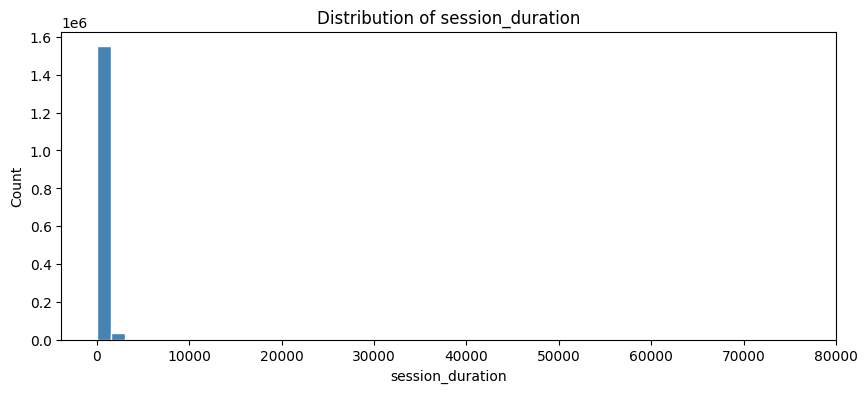

In [ ]:
print(f'dtype: {sessions["session_duration"].dtype}')
print(f'missing: {sessions["session_duration"].isna().sum()}')
print(f'\nmean   : {sessions["session_duration"].mean():.2f}')
print(f'median : {sessions["session_duration"].median():.2f}')
print(f'min    : {sessions["session_duration"].min():.2f}')
print(f'max    : {sessions["session_duration"].max():.2f}')

plt.figure(figsize=(10, 4))
plt.hist(sessions['session_duration'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of session_duration')
plt.xlabel('session_duration')
plt.ylabel('Count')
plt.show()

check outlier

In [ ]:
Q1  = sessions['session_duration'].quantile(0.25)
Q3  = sessions['session_duration'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR

outliers = sessions[sessions['session_duration'] > upper]
print(f'Q1     : {Q1:.2f}')
print(f'Q3     : {Q3:.2f}')
print(f'IQR    : {IQR:.2f}')
print(f'upper  : {upper:.2f}')
print(f'outliers: {len(outliers):,} แถว ({len(outliers)/len(sessions)*100:.2f}%)')

Q1     : 116.51
Q3     : 566.18
IQR    : 449.67
upper  : 1915.20
outliers: 25,877 แถว (1.62%)


### pages_viewed

In [ ]:
print(f'dtype: {sessions["pages_viewed"].dtype}')
print(f'missing: {sessions["pages_viewed"].isna().sum()}')
print(f'\nvalue_counts:')
print(sessions['pages_viewed'].value_counts().sort_index())

dtype: float64
missing: 79889

value_counts:
pages_viewed
0.0       3759
1.0      22358
2.0      67792
3.0     135260
4.0     202903
5.0     243555
6.0     244379
7.0     210047
8.0     156880
9.0     104880
10.0     63121
11.0     34525
12.0     17137
13.0      7949
14.0      3341
15.0      1308
16.0       476
17.0       181
18.0        63
19.0        23
20.0         4
21.0         1
Name: count, dtype: int64


impute

In [ ]:
# เก็บ NaN ไว้ใน pages_viewed แต่แปลงเป็น nullable int
sessions['pages_viewed'] = sessions['pages_viewed'].astype('Int64')

# สร้าง pages_viewed_imputed ด้วย median แล้วแปลงเป็น int
median_pages = sessions['pages_viewed'].median()
sessions['pages_viewed_imputed'] = sessions['pages_viewed'].fillna(median_pages).astype(int)

print(f'pages_viewed dtype         : {sessions["pages_viewed"].dtype}')
print(f'pages_viewed_imputed dtype : {sessions["pages_viewed_imputed"].dtype}')
print(f'pages_viewed missing       : {sessions["pages_viewed"].isna().sum()}')
print(f'pages_viewed_imputed missing: {sessions["pages_viewed_imputed"].isna().sum()}')
print(f'median ที่ใช้ impute: {median_pages}')

pages_viewed dtype         : Int64
pages_viewed_imputed dtype : int64
pages_viewed missing       : 79889
pages_viewed_imputed missing: 0
median ที่ใช้ impute: 6.0


### cart_additions

In [ ]:
print(f'dtype: {sessions["cart_additions"].dtype}')
print(f'missing: {sessions["cart_additions"].isna().sum()}')
print(f'\nvalue_counts:')
print(sessions['cart_additions'].value_counts().sort_index())

dtype: int64
missing: 0

value_counts:
cart_additions
0     216452
1     433579
2     433017
3     288461
4     144351
5      57441
6      19192
7       5541
8       1403
9        318
10        68
11         6
12         1
13         1
Name: count, dtype: int64


### bounce_flag

In [ ]:
print(f'dtype: {sessions["bounce_flag"].dtype}')
print(f'missing: {sessions["bounce_flag"].isna().sum()}')
print(f'\nvalue_counts:')
print(sessions['bounce_flag'].value_counts())

dtype: object
missing: 0

value_counts:
bounce_flag
0        267521
1        266977
No       266946
TRUE     266380
FALSE    266097
Yes      265910
Name: count, dtype: int64


จัดการ inconsistent format

In [ ]:
bool_map = {'true': 1, '1': 1, 'yes': 1,
            'false': 0, '0': 0, 'no': 0}

sessions['bounce_flag'] = (sessions['bounce_flag']
                           .astype(str).str.strip().str.lower()
                           .map(bool_map))

print(f'missing: {sessions["bounce_flag"].isna().sum()}')
print(sessions['bounce_flag'].value_counts())

missing: 0
bounce_flag
0    800564
1    799267
Name: count, dtype: int64


### traffic_source

In [ ]:
print(f'dtype: {sessions["traffic_source"].dtype}')
print(f'missing: {sessions["traffic_source"].isna().sum()}')
print(f'\nvalue_counts:')
print(sessions['traffic_source'].value_counts())

dtype: object
missing: 0

value_counts:
traffic_source
SOCIAL     267332
organic    267167
email      266773
Ads        266740
Organic    265911
ads        265908
Name: count, dtype: int64


inconsistent format

In [ ]:
sessions['traffic_source'] = sessions['traffic_source'].str.strip().str.lower()

print(sessions['traffic_source'].value_counts())

traffic_source
organic    533078
ads        532648
social     267332
email      266773
Name: count, dtype: int64


### device_type

In [ ]:
print(f'dtype: {sessions["device_type"].dtype}')
print(f'missing: {sessions["device_type"].isna().sum()}')
print(f'\nvalue_counts:')
print(sessions['device_type'].value_counts())

dtype: object
missing: 0

value_counts:
device_type
Desktop    320841
Mobile     320608
desktop    320535
mobile     319325
TABLET     318522
Name: count, dtype: int64


inconsistency format

In [ ]:
sessions['device_type'] = sessions['device_type'].str.strip().str.lower()

print(sessions['device_type'].value_counts())

device_type
desktop    641376
mobile     639933
tablet     318522
Name: count, dtype: int64


## (aggregate) Dataset session + transaction

### Merge session + geo + campaigns

In [ ]:
sessions_geo_campaign = sessions.merge(geo, on='geo_ip_region', how='left')
sessions_geo_campaign = sessions_geo_campaign.merge(campaigns, on='campaign_id', how='left')

print(f'shape: {sessions_geo_campaign.shape}')
print(f'\ncolumns: {list(sessions_geo_campaign.columns)}')
print(f'\nMissing:')
print(sessions_geo_campaign.isnull().sum()[sessions_geo_campaign.isnull().sum() > 0])

shape: (1599831, 22)

columns: ['session_id', 'customer_id', 'session_timestamp', 'session_duration', 'pages_viewed', 'cart_additions', 'bounce_flag', 'traffic_source', 'device_type', 'campaign_id', 'geo_ip_region', 'pages_viewed_imputed', 'average_income', 'urban_ratio', 'internet_penetration', 'region_tier_encode', 'campaign_type', 'campaign_budget', 'region_target', 'start_date', 'end_date', 'campaign_duration_days']

Missing:
pages_viewed    79889
dtype: int64


drop start_date,end_date ของ campaign เพราะเอาไปคิดเป็น duration แล้ว

In [ ]:
sessions_geo_campaign.drop(columns=['start_date', 'end_date'], inplace=True)

การ Aggregate sessions_geo_campaign
ตาราง sessions_geo_campaign มาจากการ join sessions + geo + campaigns ไว้แล้ว มีทั้งหมด 1,599,831 แถว ซึ่งแต่ละแถวคือ 1 session ของลูกค้าคนใดคนหนึ่ง เป้าหมายคือ aggregate ให้เหลือ 1 แถวต่อ 1 customer เพื่อนำไป merge กับ customers และ train ต่อไป
วิธี aggregate แต่ละกลุ่ม
sessions ใช้ count, mean, sum, max ตามความเหมาะสมของแต่ละตัวแปร เช่น session_duration ใช้ mean และ max เพื่อดูทั้งค่าเฉลี่ยและค่าสูงสุด
pages_viewed aggregate 2 แบบ คือแบบที่ยังมี NaN ไว้ให้ tree model จัดการเอง และแบบ imputed เผื่อใช้กับ model ที่รับ NaN ไม่ได้
timestamp คำนวณ days_since_last_session โดยใช้ reference_date คือวันล่าสุดในข้อมูล (2024-09-26) ลบด้วย session ล่าสุดของลูกค้าแต่ละคน บอกว่าลูกค้าเข้ามาใช้งานล่าสุดนานแค่ไหนแล้ว
categorical columns อย่าง traffic_source, device_type, campaign_type แปลงเป็น pct_ แต่ละประเภท เพื่อให้ model เห็นสัดส่วนการใช้งานแต่ละประเภทของลูกค้าแต่ละคน
geo ใช้ mean ของ average_income, urban_ratio, internet_penetration, region_tier_encode เพื่อสรุปลักษณะของ region ที่ลูกค้าเคย session มา
campaigns ใช้ mean ของ campaign_budget และ campaign_duration_days เพื่อสรุปลักษณะของ campaign ที่ลูกค้าเคยเจอ
ทำไมตัด region_target ทิ้ง
region_target บอกว่า campaign ตั้งใจ target region ไหน แต่ไม่ได้แปลว่าลูกค้าที่เจอ campaign นั้นอยู่ใน region นั้นจริงๆ นอกจากนี้ข้อมูล region จริงๆ ของลูกค้ามีอยู่แล้วใน geo_ip_region และ region_tier_encode ซึ่งแม่นยำกว่า และ region_target มี 100 unique values ถ้าทำเป็น pct_ จะได้ features เพิ่มมาอีก 100 ตัวโดยไม่จำเป็นค่ะ

In [ ]:
reference_date = pd.Timestamp('2024-09-26')

# aggregate หลักด้วย groupby
sess_agg = sessions_geo_campaign.groupby('customer_id').agg(
    total_sessions              = ('session_id',                'count'),
    days_since_last_session     = ('session_timestamp',         lambda x: (reference_date - x.max()).days),
    avg_session_duration        = ('session_duration',          'mean'),
    max_session_duration        = ('session_duration',          'max'),
    avg_pages_viewed            = ('pages_viewed',              'mean'),
    total_pages_viewed          = ('pages_viewed',              'sum'),
    avg_pages_viewed_imputed    = ('pages_viewed_imputed',      'mean'),
    total_pages_viewed_imputed  = ('pages_viewed_imputed',      'sum'),
    total_cart_additions        = ('cart_additions',            'sum'),
    avg_cart_additions          = ('cart_additions',            'mean'),
    bounce_rate                 = ('bounce_flag',               'mean'),
    avg_income                  = ('average_income',            'mean'),
    avg_urban_ratio             = ('urban_ratio',               'mean'),
    avg_internet_penetration    = ('internet_penetration',      'mean'),
    avg_region_tier             = ('region_tier_encode',        'mean'),
    avg_campaign_budget         = ('campaign_budget',           'mean'),
    avg_campaign_duration       = ('campaign_duration_days',    'mean'),
).reset_index()

# pct traffic_source
traffic_pct = (sessions_geo_campaign.groupby('customer_id')['traffic_source']
               .value_counts(normalize=True)
               .unstack(fill_value=0)
               .add_prefix('pct_traffic_')
               .reset_index())
traffic_pct.columns.name = None

# pct device_type
device_pct = (sessions_geo_campaign.groupby('customer_id')['device_type']
              .value_counts(normalize=True)
              .unstack(fill_value=0)
              .add_prefix('pct_device_')
              .reset_index())
device_pct.columns.name = None

# pct campaign_type
campaign_pct = (sessions_geo_campaign.groupby('customer_id')['campaign_type']
                .value_counts(normalize=True)
                .unstack(fill_value=0)
                .add_prefix('pct_campaign_')
                .reset_index())
campaign_pct.columns.name = None

# merge รวมกัน
sess_agg = sess_agg.merge(traffic_pct,  on='customer_id', how='left')
sess_agg = sess_agg.merge(device_pct,   on='customer_id', how='left')
sess_agg = sess_agg.merge(campaign_pct, on='customer_id', how='left')

print(f'shape: {sess_agg.shape}')
print(f'columns: {list(sess_agg.columns)}')
print(f'\nMissing:')
print(sess_agg.isnull().sum()[sess_agg.isnull().sum() > 0])
sess_agg.head(3)

shape: (159993, 30)
columns: ['customer_id', 'total_sessions', 'days_since_last_session', 'avg_session_duration', 'max_session_duration', 'avg_pages_viewed', 'total_pages_viewed', 'avg_pages_viewed_imputed', 'total_pages_viewed_imputed', 'total_cart_additions', 'avg_cart_additions', 'bounce_rate', 'avg_income', 'avg_urban_ratio', 'avg_internet_penetration', 'avg_region_tier', 'avg_campaign_budget', 'avg_campaign_duration', 'pct_traffic_ads', 'pct_traffic_email', 'pct_traffic_organic', 'pct_traffic_social', 'pct_device_desktop', 'pct_device_mobile', 'pct_device_tablet', 'pct_campaign_Affiliate', 'pct_campaign_Display', 'pct_campaign_Email', 'pct_campaign_Search', 'pct_campaign_Social']

Missing:
avg_pages_viewed    3
dtype: int64


,customer_id,total_sessions,days_since_last_session,avg_session_duration,max_session_duration,avg_pages_viewed,total_pages_viewed,avg_pages_viewed_imputed,total_pages_viewed_imputed,total_cart_additions,...,pct_traffic_organic,pct_traffic_social,pct_device_desktop,pct_device_mobile,pct_device_tablet,pct_campaign_Affiliate,pct_campaign_Display,pct_campaign_Email,pct_campaign_Search,pct_campaign_Social
0,0,12,109,406.994775,1317.053930,7.416667,89,7.416667,89,29,...,0.333333,0.250000,0.416667,0.416667,0.166667,0.000000,0.416667,0.083333,0.166667,0.333333
1,1,11,128,378.574424,1608.876532,4.727273,52,4.727273,52,19,...,0.454545,0.090909,0.272727,0.454545,0.272727,0.090909,0.454545,0.272727,0.090909,0.090909
2,2,13,69,465.061096,1542.495096,7.076923,92,7.076923,92,33,...,0.307692,0.230769,0.461538,0.307692,0.230769,0.230769,0.307692,0.076923,0.153846,0.230769


### transaction

In [ ]:
trans_agg = transactions.groupby('customer_id').agg(
    total_transactions          = ('transaction_id',          'count'),
    days_since_last_transaction = ('transaction_timestamp',   lambda x: (reference_date - x.max()).days),
    total_spend                 = ('order_value',             'sum'),
    avg_order_value             = ('order_value',             'mean'),
    max_order_value             = ('order_value',             'max'),
    total_items                 = ('items_count',             'sum'),
    avg_items                   = ('items_count',             'mean'),
    discount_rate               = ('discount_applied',        'mean'),
    high_value_rate             = ('high_value_flag_encode',  'mean'),
).reset_index()

# pct payment_method
payment_pct = (transactions.groupby('customer_id')['payment_method']
               .value_counts(normalize=True)
               .unstack(fill_value=0)
               .add_prefix('pct_payment_')
               .reset_index())
payment_pct.columns.name = None

# pct shipping_speed
shipping_pct = (transactions.groupby('customer_id')['shipping_speed']
                .value_counts(normalize=True)
                .unstack(fill_value=0)
                .add_prefix('pct_shipping_')
                .reset_index())
shipping_pct.columns.name = None

# merge รวมกัน
trans_agg = trans_agg.merge(payment_pct,  on='customer_id', how='left')
trans_agg = trans_agg.merge(shipping_pct, on='customer_id', how='left')

print(f'shape: {trans_agg.shape}')
print(f'columns: {list(trans_agg.columns)}')
print(f'\nMissing:')
print(trans_agg.isnull().sum()[trans_agg.isnull().sum() > 0])
trans_agg.head(3)

shape: (146860, 17)
columns: ['customer_id', 'total_transactions', 'days_since_last_transaction', 'total_spend', 'avg_order_value', 'max_order_value', 'total_items', 'avg_items', 'discount_rate', 'high_value_rate', 'pct_payment_credit_card', 'pct_payment_crypto', 'pct_payment_debit_card', 'pct_payment_paypal', 'pct_shipping_express', 'pct_shipping_overnight', 'pct_shipping_standard']

Missing:
Series([], dtype: int64)


,customer_id,total_transactions,days_since_last_transaction,total_spend,avg_order_value,max_order_value,total_items,avg_items,discount_rate,high_value_rate,pct_payment_credit_card,pct_payment_crypto,pct_payment_debit_card,pct_payment_paypal,pct_shipping_express,pct_shipping_overnight,pct_shipping_standard
0,0,2,530,339.90,169.950,219.75,7,3.5,0.5,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,2,782,147.03,73.515,107.22,4,2.0,0.0,0.0,0.5,0.0,0.0,0.5,1.0,0.0,0.0
2,2,1,117,43.46,43.460,43.46,5,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## (ไม่ aggregate) Dataset session + transaction
Especially for LSTM

Transaction row:
campaign_type, campaign_budget, region_target
     → จาก campaign ที่ active (between start_date & end_date)
     → ถ้าไม่มี → 'none' / 0


geo_ip_region, avg_income, urban_ratio,
    internet_penetration, region_tier
      → จาก session ล่าสุดไม่เกิน 14 วัน
      → ถ้าไม่มี → 'unknown' / 0

In [ ]:
sessions_campaigns = sessions.merge(
    campaigns,
    on='campaign_id',
    how='left')

sessions_campaigns_geo = sessions_campaigns.merge(
    geo,
    on='geo_ip_region',
    how='left')

sessions_campaigns_geo.head()

,session_id,customer_id,session_timestamp,session_duration,pages_viewed,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,...,campaign_type,campaign_budget,region_target,start_date,end_date,campaign_duration_days,average_income,urban_ratio,internet_penetration,region_tier_encode
0,0,98947,2022-01-26,699.425135,2,4,0,organic,desktop,105,...,Search,121195,region_59,2022-02-18,2022-05-13,84,10703.823439,0.694179,0.855785,1.0
1,1,180169,2023-05-19,127.086666,8,2,0,organic,mobile,155,...,Social,276765,region_77,2022-02-20,2022-05-05,74,41565.687061,0.323977,0.954876,1.0
2,2,196195,2022-03-24,99.648727,3,3,1,organic,desktop,183,...,Display,460009,region_65,2022-10-30,2023-01-13,75,20604.948142,0.421237,0.844217,1.0
3,3,92468,2023-05-20,1.660842,3,2,0,ads,desktop,39,...,Display,148013,region_83,2022-11-24,2023-02-01,69,39846.169995,0.901051,0.684036,1.0
4,4,21053,2024-07-06,867.507773,5,0,0,organic,mobile,139,...,Email,482930,region_39,2022-02-24,2022-06-12,108,49462.609413,0.405059,0.764911,3.0


In [ ]:
sessions_campaigns_geo.columns

Index(['session_id', 'customer_id', 'session_timestamp', 'session_duration',
       'pages_viewed', 'cart_additions', 'bounce_flag', 'traffic_source',
       'device_type', 'campaign_id', 'geo_ip_region', 'pages_viewed_imputed',
       'campaign_type', 'campaign_budget', 'region_target', 'start_date',
       'end_date', 'campaign_duration_days', 'average_income', 'urban_ratio',
       'internet_penetration', 'region_tier_encode'],
      dtype='object')

In [ ]:
# ============================================================
# STEP 1: เตรียม sessions_seq
# ============================================================

sessions_seq = sessions_campaigns_geo[[
       'customer_id', 'session_timestamp', 'session_duration',
       'cart_additions', 'bounce_flag', 'traffic_source',
       'device_type', 'campaign_id', 'geo_ip_region', 'pages_viewed_imputed',
       'campaign_type', 'campaign_budget', 'region_target', 'start_date',
       'end_date', 'campaign_duration_days', 'average_income', 'urban_ratio',
       'internet_penetration', 'region_tier_encode'
]].copy()

sessions_seq['event_type'] = 0
sessions_seq['order_value'] = 0
sessions_seq['items_count'] = 0
sessions_seq['payment_method'] = None
sessions_seq['shipping_speed'] = None
sessions_seq['discount_applied'] = 0
sessions_seq['high_value_flag_encode'] = 0
sessions_seq.rename(columns={'session_timestamp': 'timestamp'}, inplace=True)

# ============================================================
# STEP 2: เตรียม transactions_seq
# ============================================================

transactions_seq = transactions[[
    'customer_id', 'transaction_timestamp',
    'order_value', 'items_count', 'payment_method', 'shipping_speed',
    'discount_applied', 'high_value_flag_encode'
]].copy()
transactions_seq['event_type']           = 1
transactions_seq['session_duration']     = 0
transactions_seq['pages_viewed_imputed'] = 0
transactions_seq['cart_additions']       = 0
transactions_seq['bounce_flag']          = 0
transactions_seq['traffic_source']       = None
transactions_seq['device_type']          = None
transactions_seq['campaign_id']          = None     # ← เพิ่ม
transactions_seq.rename(columns={'transaction_timestamp': 'timestamp'}, inplace=True)
transactions_seq['timestamp'] = pd.to_datetime(transactions_seq['timestamp'])

# --- Case 1: Campaign info จาก start_date และ end_date ---
campaigns_info = sessions_campaigns_geo[[
    'campaign_type', 'campaign_budget',
    'region_target', 'start_date', 'end_date',
    'campaign_duration_days'
]].drop_duplicates().copy()

campaigns_info['start_date'] = pd.to_datetime(campaigns_info['start_date'])
campaigns_info['end_date']   = pd.to_datetime(campaigns_info['end_date'])

campaign_records = []
for _, camp in campaigns_info.iterrows():
    mask = (
        (transactions_seq['timestamp'] >= camp['start_date']) &
        (transactions_seq['timestamp'] <= camp['end_date'])
    )
    matched = transactions_seq[mask][['customer_id', 'timestamp']].copy()
    matched['campaign_type']         = camp['campaign_type']
    matched['campaign_budget']       = camp['campaign_budget']
    matched['region_target']         = camp['region_target']
    matched['start_date']            = camp['start_date']
    matched['end_date']              = camp['end_date']
    matched['campaign_duration_days']= camp['campaign_duration_days']  # ← เพิ่ม
    campaign_records.append(matched)


if campaign_records:
    transactions_with_campaign = pd.concat(campaign_records, ignore_index=True)

    # ถ้ามีหลาย campaign active → เลือก budget สูงสุด
    transactions_with_campaign = transactions_with_campaign.sort_values(
        'campaign_budget', ascending=False
    ).drop_duplicates(subset=['customer_id', 'timestamp'])
    print("Matched transactions with campaign:", len(transactions_with_campaign))

    transactions_seq = transactions_seq.merge(
        transactions_with_campaign[[
            'customer_id', 'timestamp',
            'campaign_type', 'campaign_budget', 'region_target',
            'start_date', 'end_date','campaign_duration_days'
        ]],
        on=['customer_id', 'timestamp'],
        how='left'
    )
    print("campaign_type not null:", transactions_seq['campaign_type'].notna().sum())
else:
    transactions_seq['campaign_type']          = 'none'
    transactions_seq['campaign_budget']        = 0
    transactions_seq['region_target']          = 'unknown'
    transactions_seq['start_date']             = pd.NaT   # ← เพิ่ม
    transactions_seq['end_date']               = pd.NaT   # ← เพิ่ม
    transactions_seq['campaign_duration_days'] = 0

# --- Case 2: Geo info จาก session ล่าสุดไม่เกิน 14 วัน ---
sessions_geo = sessions_campaigns_geo[[
    'customer_id', 'session_timestamp',
    'geo_ip_region', 'average_income',
    'urban_ratio', 'internet_penetration', 'region_tier_encode'
]].copy()
sessions_geo['session_timestamp'] = pd.to_datetime(sessions_geo['session_timestamp'])
sessions_geo     = sessions_geo.sort_values('session_timestamp').reset_index(drop=True)
transactions_seq = transactions_seq.sort_values('timestamp').reset_index(drop=True)

transactions_seq = pd.merge_asof(
    transactions_seq,
    sessions_geo.rename(columns={'session_timestamp': 'timestamp'}),
    on='timestamp',
    by='customer_id',
    direction='backward',
    tolerance=pd.Timedelta('14 days')
)

# fillna
transactions_seq['campaign_type'].fillna('none', inplace=True)
transactions_seq['campaign_budget'].fillna(0, inplace=True)
transactions_seq['region_target'].fillna('unknown', inplace=True)
transactions_seq['geo_ip_region'].fillna('unknown', inplace=True)
transactions_seq['average_income'].fillna(0, inplace=True)
transactions_seq['urban_ratio'].fillna(0, inplace=True)
transactions_seq['internet_penetration'].fillna(0, inplace=True)
transactions_seq['region_tier_encode'].fillna(0, inplace=True)

# ============================================================
# STEP 3: Concat + Sort
# (drop start_date, end_date จาก sessions_seq ก่อน concat
#  เพราะ transactions_seq ไม่มี 2 columns นี้แล้ว)
# ============================================================

unified = pd.concat([sessions_seq, transactions_seq], ignore_index=True)
unified['timestamp'] = pd.to_datetime(unified['timestamp'])
unified = unified.sort_values(['customer_id', 'timestamp']).reset_index(drop=True)

# ============================================================
# STEP 4: Join customers
# ============================================================

unified = unified.merge(
    customers[['customer_id', 'country_code', 'region', 'signup_date', 'loyalty_score',
       'discount_usage_rate', 'avg_review_score', 'credit_limit',
       'age_imputed', 'email_open_rate_imputed', 'customer_tier_encode']], # Removed duplicate 'loyalty_score'
    on='customer_id', how='left'
)

print("Shape:", unified.shape)
print("Event type counts:\n", unified['event_type'].value_counts())
print("Campaign null rate:", unified['campaign_type'].isna().mean())
print("Geo null rate:", unified['geo_ip_region'].isna().mean())
print("Columns:", unified.columns.tolist())

Matched transactions with campaign: 190194
campaign_type not null: 190436


/tmp/ipykernel_750/1528603698.py:116: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transactions_seq['campaign_type'].fillna('none', inplace=True)
/tmp/ipykernel_750/1528603698.py:117: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

Shape: (2000058, 37)
Event type counts:
 event_type
0    1599831
1     400227
Name: count, dtype: int64
Campaign null rate: 0.0
Geo null rate: 0.0
Columns: ['customer_id', 'timestamp', 'session_duration', 'cart_additions', 'bounce_flag', 'traffic_source', 'device_type', 'campaign_id', 'geo_ip_region', 'pages_viewed_imputed', 'campaign_type', 'campaign_budget', 'region_target', 'start_date', 'end_date', 'campaign_duration_days', 'average_income', 'urban_ratio', 'internet_penetration', 'region_tier_encode', 'event_type', 'order_value', 'items_count', 'payment_method', 'shipping_speed', 'discount_applied', 'high_value_flag_encode', 'country_code', 'region', 'signup_date', 'loyalty_score', 'discount_usage_rate', 'avg_review_score', 'credit_limit', 'age_imputed', 'email_open_rate_imputed', 'customer_tier_encode']


In [ ]:
unified.head()

,customer_id,timestamp,session_duration,cart_additions,bounce_flag,traffic_source,device_type,campaign_id,geo_ip_region,pages_viewed_imputed,...,country_code,region,signup_date,loyalty_score,discount_usage_rate,avg_review_score,credit_limit,age_imputed,email_open_rate_imputed,customer_tier_encode
0,0,2022-01-10,0.000000,0,0,None,None,None,unknown,0,...,USA,region_50,2022-08-02,0.244,0.23817,4.837508,10966,73.0,0.660207,0
1,0,2022-03-30,77.391999,2,1,ads,mobile,123,region_74,10,...,USA,region_50,2022-08-02,0.244,0.23817,4.837508,10966,73.0,0.660207,0
2,0,2022-04-29,205.465279,0,0,social,desktop,80,region_60,10,...,USA,region_50,2022-08-02,0.244,0.23817,4.837508,10966,73.0,0.660207,0
3,0,2022-06-12,309.962594,2,1,organic,desktop,141,region_93,5,...,USA,region_50,2022-08-02,0.244,0.23817,4.837508,10966,73.0,0.660207,0
4,0,2022-12-30,428.906691,4,0,organic,mobile,97,region_25,7,...,USA,region_50,2022-08-02,0.244,0.23817,4.837508,10966,73.0,0.660207,0


### Feature Engineering


*   เพิ่ม columns: **region_match, traffic_campaign_match**
*   drop columns: **start_date, end_date, geo_ip_region, region_target, country_code, region, signup_date**

In [ ]:
unified.isnull().sum()

,0
customer_id,0
timestamp,0
session_duration,0
cart_additions,0
bounce_flag,0
traffic_source,400227
device_type,400227
campaign_id,400227
geo_ip_region,0
pages_viewed_imputed,0


In [ ]:
# region_match = geo ของลูกค้าตรงกับ region ที่ campaign target มั้ย
unified['region_match'] = (
    unified['geo_ip_region'].fillna('') ==
    unified['region_target'].fillna('')
).astype(int)

# traffic_campaign_match = traffic source ตรงกับ campaign type มั้ย
unified['traffic_campaign_match'] = (
    unified['traffic_source'].fillna('').str.lower() ==
    unified['campaign_type'].fillna('').str.lower()
).astype(int)

In [ ]:
# drop columns ที่ใช้ไปแล้ว
unified.drop(columns=[
    'start_date', 'end_date',
    'geo_ip_region', 'region_target',
    'country_code', 'region', 'signup_date'
], inplace=True)

print("Shape:", unified.shape)
print("Columns:", unified.columns.tolist())
print("Null rates:\n", unified.isnull().mean().sort_values(ascending=False).head(10))

Shape: (2000058, 32)
Columns: ['customer_id', 'timestamp', 'session_duration', 'cart_additions', 'bounce_flag', 'traffic_source', 'device_type', 'campaign_id', 'pages_viewed_imputed', 'campaign_type', 'campaign_budget', 'campaign_duration_days', 'average_income', 'urban_ratio', 'internet_penetration', 'region_tier_encode', 'event_type', 'order_value', 'items_count', 'payment_method', 'shipping_speed', 'discount_applied', 'high_value_flag_encode', 'loyalty_score', 'discount_usage_rate', 'avg_review_score', 'credit_limit', 'age_imputed', 'email_open_rate_imputed', 'customer_tier_encode', 'region_match', 'traffic_campaign_match']
Null rates:
 shipping_speed            0.799892
payment_method            0.799892
device_type               0.200108
campaign_id               0.200108
traffic_source            0.200108
campaign_duration_days    0.104892
cart_additions            0.000000
session_duration          0.000000
bounce_flag               0.000000
pages_viewed_imputed      0.000000
dt

In [ ]:
print("\nสรุป:")
print(f"Total rows: {len(unified)}")
print(f"Session rows (event_type=0): {(unified['event_type']==0).sum()}")
print(f"Transaction rows (event_type=1): {(unified['event_type']==1).sum()}")
print(f"Rows ที่มี campaign (duration > 0): {(unified['campaign_duration_days'] > 0).sum()}")
print(f"Rows ที่ไม่มี campaign (duration = 0): {(unified['campaign_duration_days'] == 0).sum()}")


สรุป:
Total rows: 2000058
Session rows (event_type=0): 1599831
Transaction rows (event_type=1): 400227
Rows ที่มี campaign (duration > 0): 1790267
Rows ที่ไม่มี campaign (duration = 0): 0


### Encoding

In [ ]:
unified = pd.get_dummies(unified, columns=['device_type', 'traffic_source', 'campaign_type',
                                            'payment_method', 'shipping_speed'],
                         prefix=['device', 'traffic', 'campaign', 'payment', 'shipping'],
                         dummy_na=False,dtype=int)
print("Shape after get_dummies:", unified.shape)

Shape after get_dummies: (2000058, 47)


In [ ]:
unified.columns.tolist()

['customer_id',
 'timestamp',
 'session_duration',
 'cart_additions',
 'bounce_flag',
 'campaign_id',
 'pages_viewed_imputed',
 'campaign_budget',
 'campaign_duration_days',
 'average_income',
 'urban_ratio',
 'internet_penetration',
 'region_tier_encode',
 'event_type',
 'order_value',
 'items_count',
 'discount_applied',
 'high_value_flag_encode',
 'loyalty_score',
 'discount_usage_rate',
 'avg_review_score',
 'credit_limit',
 'age_imputed',
 'email_open_rate_imputed',
 'customer_tier_encode',
 'region_match',
 'traffic_campaign_match',
 'device_desktop',
 'device_mobile',
 'device_tablet',
 'traffic_ads',
 'traffic_email',
 'traffic_organic',
 'traffic_social',
 'campaign_Affiliate',
 'campaign_Display',
 'campaign_Email',
 'campaign_Search',
 'campaign_Social',
 'campaign_none',
 'payment_credit_card',
 'payment_crypto',
 'payment_debit_card',
 'payment_paypal',
 'shipping_express',
 'shipping_overnight',
 'shipping_standard']

In [ ]:
# fillna ทุก column ยกเว้น target
cols_to_fill = [c for c in unified.columns if c != 'target']
unified[cols_to_fill]  = unified[cols_to_fill].fillna(0)

print("Null counts after fillna:")
print(unified.isnull().sum().sum())

/tmp/ipykernel_750/1056059874.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  unified[cols_to_fill]  = unified[cols_to_fill].fillna(0)


Null counts after fillna:
0


In [ ]:
# นับจำนวน events ต่อลูกค้า
events_per_customer = unified.groupby('customer_id').size()

print(events_per_customer.describe())
print("\nPercentiles:")
print(events_per_customer.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

count    159999.000000
mean         12.500441
std           3.528554
min           1.000000
25%          10.000000
50%          12.000000
75%          15.000000
max          30.000000
dtype: float64

Percentiles:
0.25    10.0
0.50    12.0
0.75    15.0
0.90    17.0
0.95    19.0
0.99    21.0
dtype: float64


เลือก ** timestep = 15 ** ที่ 75th percentile เพราะว่า
หากเลือกที่ 50th percentile ตัด/pad ลูกค้าครึ่งนึงทำให้ เสีย sequential information เยอะเกินไป
LSTM ไม่ได้เห็น pattern ที่สำคัญของลูกค้าที่ active มากๆ
และการเลือกที่ percentile มากกว่านี้จะทำให้ใช้เวลานานมาก และมี padding ที่เยอะเกินไป

**75th percentile จึงเป็นจุดที่ ได้ข้อมูลเพียงพอสำหรับ LSTM โดยไม่สิ้นเปลือง RAM และเวลา train มากเกินไป**

# LSTM

### Train Test Split

In [ ]:


# แยก train/test
from sklearn.model_selection import train_test_split

# unified ยังไม่มี target → merge กับ train เพื่อเอา target มา
unified = unified.merge(
    train[['customer_id', 'target']],
    on='customer_id',
    how='inner'  # เอาเฉพาะ customer ที่อยู่ใน train
)

# ดึง unique customer_ids จาก unified_train
customer_ids_all = unified['customer_id'].unique()

# แบ่ง customer_ids เป็น train/val 80/20
train_customer_ids, val_customer_ids = train_test_split(
    customer_ids_all,
    test_size=0.2,
    random_state=42
)

print(f"Train customers: {len(train_customer_ids)}")
print(f"Val customers:   {len(val_customer_ids)}")

# แบ่ง unified_train ตาม customer_ids
split_train = unified[unified['customer_id'].isin(train_customer_ids)]
split_val   = unified[unified['customer_id'].isin(val_customer_ids)]

print(f"\nTrain rows: {split_train.shape[0]}")
print(f"Val rows:   {split_val.shape[0]}")

# เช็ค target distribution
print(f"\nTrain target distribution:")
print(split_train.groupby('customer_id')['target'].first().value_counts())
print(f"\nVal target distribution:")
print(split_val.groupby('customer_id')['target'].first().value_counts())

Train customers: 127999
Val customers:   32000

Train rows: 1600030
Val rows:   400028

Train target distribution:
target
0    101927
1     26072
Name: count, dtype: int64

Val target distribution:
target
0    25586
1     6414
Name: count, dtype: int64


### Standard Scaler

In [ ]:
unified[['session_duration','pages_viewed_imputed','cart_additions',
 'pages_viewed_imputed','campaign_budget',
 'campaign_duration_days','average_income','urban_ratio',
 'internet_penetration','region_tier_encode','order_value',
 'items_count','loyalty_score','discount_usage_rate',
 'avg_review_score','credit_limit','age_imputed',
 'email_open_rate_imputed','customer_tier_encode']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000058 entries, 0 to 2000057
Data columns (total 19 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   session_duration         float64
 1   pages_viewed_imputed     int64  
 2   cart_additions           int64  
 3   pages_viewed_imputed     int64  
 4   campaign_budget          float64
 5   campaign_duration_days   float64
 6   average_income           float64
 7   urban_ratio              float64
 8   internet_penetration     float64
 9   region_tier_encode       float64
 10  order_value              float64
 11  items_count              int64  
 12  loyalty_score            float64
 13  discount_usage_rate      float64
 14  avg_review_score         float64
 15  credit_limit             int64  
 16  age_imputed              float64
 17  email_open_rate_imputed  float64
 18  customer_tier_encode     int64  
dtypes: float64(13), int64(6)
memory usage: 289.9 MB


In [ ]:
from sklearn.preprocessing import StandardScaler
num_cols = [
'session_duration','pages_viewed_imputed','cart_additions',
 'pages_viewed_imputed','campaign_budget',
 'campaign_duration_days','average_income','urban_ratio',
 'internet_penetration','region_tier_encode','order_value',
 'items_count','loyalty_score','discount_usage_rate',
 'avg_review_score','credit_limit','age_imputed',
 'email_open_rate_imputed','customer_tier_encode','high_value_flag_encode'
]

print(f"Continuous cols to scale: {len(num_cols)}")


scaler = StandardScaler()

# fit บน train เท่านั้น → transform ทั้งคู่
split_train[num_cols] = scaler.fit_transform(
    split_train[num_cols].fillna(0)
)
split_val[num_cols] = scaler.transform(
    split_val[num_cols].fillna(0)
)

print("Scaling done ")
print("event_type values:", split_train['event_type'].unique())
print("\nSample scaled values (train):")
print(split_train[num_cols[:3]].head(3))

Continuous cols to scale: 20


/tmp/ipykernel_750/1718103356.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split_train[num_cols] = scaler.fit_transform(
/tmp/ipykernel_750/1718103356.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split_val[num_cols] = scaler.transform(


Scaling done 
event_type values: [1 0]

Sample scaled values (train):
    session_duration  pages_viewed_imputed  cart_additions
14         -0.357213             -1.494275       -1.068493
15         -0.002910             -0.249618        2.274905
16         -0.269437              0.372710       -0.399814


### Build Tensor

In [ ]:
# ============================================================
# สร้าง Tensor
# ============================================================

import numpy as np

max_timesteps    = 15
min_transactions = 1

feature_cols = [c for c in split_train.columns
                if c not in ['customer_id', 'timestamp', 'target']]

n_features = len(feature_cols)
print(f"\nn_features: {n_features}")

def get_last_events(df, max_timesteps=15, min_transactions=1):
    sessions     = df[df['event_type'] == 0]
    transactions = df[df['event_type'] == 1]

    last_tx   = transactions.tail(min_transactions)
    remaining = max_timesteps - len(last_tx)
    # Ensure remaining is not negative
    if remaining < 0:
        remaining = 0
    last_sess = sessions.tail(remaining)

    combined = pd.concat([last_tx, last_sess])
    combined = combined.sort_values('timestamp').tail(max_timesteps)
    return combined

# --- Train tensor ---
train_ids = split_train['customer_id'].unique()
X_train   = np.zeros((len(train_ids), max_timesteps, n_features))
y_train   = np.zeros(len(train_ids))

for i, cid in enumerate(train_ids):
    customer_data = split_train[split_train['customer_id'] == cid]
    events        = get_last_events(customer_data, max_timesteps, min_transactions)
    vals          = events[feature_cols].values
    if len(vals) > 0: # Add this check to prevent broadcasting empty arrays
        # Changed to right-padding: data at the beginning, zeros at the end
        X_train[i, :len(vals), :] = vals
    # The target `y_train` should be based on the customer, not on individual events
    # It's assumed each customer_id in `unified_train` has a consistent `target`
    y_train[i] = customer_data['target'].iloc[0]


# --- Validation tensor ---
val_ids = split_val['customer_id'].unique()
X_val   = np.zeros((len(val_ids), max_timesteps, n_features))
y_val   = np.zeros(len(val_ids))  # ← เพิ่ม y_val

for i, cid in enumerate(val_ids):
    customer_data = split_val[split_val['customer_id'] == cid]
    events        = get_last_events(customer_data, max_timesteps, min_transactions)
    vals          = events[feature_cols].fillna(0).values  # ← fillna
    if len(vals) > 0:
        # Changed to right-padding: data at the beginning, zeros at the end
        X_val[i, :len(vals), :] = vals
    y_val[i] = customer_data['target'].iloc[0]  # ← เพิ่ม y_val

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:  ", X_val.shape)
print("y_val shape:  ", y_val.shape)



n_features: 45

X_train shape: (127999, 15, 45)
y_train shape: (127999,)
X_val shape:   (32000, 15, 45)
y_val shape:   (32000,)


In [ ]:
# เช็ค feature_cols
print("feature_cols count:", len(feature_cols))
print("feature_cols sample:", feature_cols[:5])

# เช็ค customer แรก
first_cid = train_ids[0]
customer_data = split_train[split_train['customer_id'] == first_cid]
print("\nCustomer data shape:", customer_data.shape)
print("Customer data sample:\n", customer_data[feature_cols].head(3))

# เช็ค get_last_events
events = get_last_events(customer_data, max_timesteps, min_transactions)
print("\nEvents shape:", events.shape)
vals = events[feature_cols].values
print("vals shape:", vals.shape)
print("vals sample:", vals[:3])

feature_cols count: 45
feature_cols sample: ['session_duration', 'cart_additions', 'bounce_flag', 'campaign_id', 'pages_viewed_imputed']

Customer data shape: (13, 48)
Customer data sample:
     session_duration  cart_additions  bounce_flag  campaign_id  \
14         -0.357213       -1.068493            0            0   
15         -0.002910        2.274905            0          167   
16         -0.269437       -0.399814            1          158   

    pages_viewed_imputed  campaign_budget  campaign_duration_days  \
14             -1.494275         1.500358               -0.027539   
15             -0.249618        -0.769456               -0.389022   
16              0.372710         0.996870                0.153203   

    average_income  urban_ratio  internet_penetration  ...  campaign_Search  \
14       -1.816961    -1.770638             -2.001698  ...                0   
15        0.243864    -0.216965              1.018145  ...                0   
16        0.295060    -0.18746

### Modelling + Evaluation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense,
                                      Dropout, Masking)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- Train/Val Split ---
X_tr, X_val_inner, y_tr, y_val_inner = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_tr shape:", X_tr.shape)
print("X_val_inner shape:", X_val_inner.shape)

# --- Class Weight ---
classes = np.unique(y_tr)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_tr
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# --- Build Model ---
sequence_input = Input(shape=(max_timesteps, n_features))

x = Masking(mask_value=0.0)(sequence_input)
x = LSTM(64, return_sequences=True, use_cudnn=False)(x)
x = Dropout(0.3)(x)
x = LSTM(32, return_sequences=False, use_cudnn=False)(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=sequence_input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(
    monitor='val_AUC',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=5,
    mode='max'
)

# --- Train ---
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val_inner, y_val_inner),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- Evaluate ---
val_pred = model.predict(X_val_inner).flatten()
val_auc  = roc_auc_score(y_val_inner, val_pred)
print(f"\nValidation AUC: {val_auc:.4f}")
print(classification_report(y_val_inner, (val_pred >= 0.5).astype(int),
                             target_names=['No Buy', 'Buy']))

# --- Prepare Test Data for Submission ---
# Load the test customer IDs (assuming 'test.csv' exists and contains 'customer_id')
test_df = pd.read_csv('test.csv')
test_customer_ids_submission = test_df['customer_id'].unique()

# Filter the original unified dataframe (before adding target) for test customers
# This assumes 'unified' was created from both train and test data, or recreated for test data.
# However, the current notebook's 'unified' is only from train customers.
# So, we need to regenerate the unified structure for test customers.

# Create 'unified_test' from test customers (similar to how 'unified' was made for train)
# Re-run the preprocessing steps for test customers (using test_df instead of train)

# The most robust way is to rebuild `unified` process for test. For now, let's assume `unified` has all customer data and we just need to split.
# However, the current `unified` was merged with `train` only.
# So, we need to apply the same preprocessing steps to `test_customer_ids`.

# Assuming `customers`, `transactions`, `sessions`, `campaigns`, `geo` are already preprocessed
# and contain all customer_ids, including those in `test.csv`.

# Filter for test_customer_ids_submission
customers_test    = customers[customers['customer_id'].isin(test_customer_ids_submission)].copy()
transactions_test = transactions[transactions['customer_id'].isin(test_customer_ids_submission)].copy()
sessions_test     = sessions[sessions['customer_id'].isin(test_customer_ids_submission)].copy()

# Aggregate sessions_test, geo, campaigns
sessions_geo_campaign_test = sessions_test.merge(geo, on='geo_ip_region', how='left')
sessions_geo_campaign_test = sessions_geo_campaign_test.merge(campaigns, on='campaign_id', how='left')
sessions_geo_campaign_test.drop(columns=['start_date', 'end_date'], inplace=True)

sess_agg_test = sessions_geo_campaign_test.groupby('customer_id').agg(
    total_sessions              = ('session_id',                'count'),
    days_since_last_session     = ('session_timestamp',         lambda x: (reference_date - x.max()).days),
    avg_session_duration        = ('session_duration',          'mean'),
    max_session_duration        = ('session_duration',          'max'),
    avg_pages_viewed            = ('pages_viewed',              'mean'),
    total_pages_viewed          = ('pages_viewed',              'sum'),
    avg_pages_viewed_imputed    = ('pages_viewed_imputed',      'mean'),
    total_pages_viewed_imputed  = ('pages_viewed_imputed',      'sum'),
    total_cart_additions        = ('cart_additions',            'sum'),
    avg_cart_additions          = ('cart_additions',            'mean'),
    bounce_rate                 = ('bounce_flag',               'mean'),
    avg_income                  = ('average_income',            'mean'),
    avg_urban_ratio             = ('urban_ratio',               'mean'),
    avg_internet_penetration    = ('internet_penetration',      'mean'),
    avg_region_tier             = ('region_tier_encode',        'mean'),
    avg_campaign_budget         = ('campaign_budget',           'mean'),
    avg_campaign_duration       = ('campaign_duration_days',    'mean'),
).reset_index()

traffic_pct_test = (sessions_geo_campaign_test.groupby('customer_id')['traffic_source']
                    .value_counts(normalize=True)
                    .unstack(fill_value=0)
                    .add_prefix('pct_traffic_')
                    .reset_index())
traffic_pct_test.columns.name = None

device_pct_test = (sessions_geo_campaign_test.groupby('customer_id')['device_type']
                   .value_counts(normalize=True)
                    .unstack(fill_value=0)
                   .add_prefix('pct_device_')
                    .reset_index())
device_pct_test.columns.name = None

campaign_pct_test = (sessions_geo_campaign_test.groupby('customer_id')['campaign_type']
                     .value_counts(normalize=True)
                     .unstack(fill_value=0)
                     .add_prefix('pct_campaign_')
                     .reset_index())
campaign_pct_test.columns.name = None

sess_agg_test = sess_agg_test.merge(traffic_pct_test,  on='customer_id', how='left')
sess_agg_test = sess_agg_test.merge(device_pct_test,   on='customer_id', how='left')
sess_agg_test = sess_agg_test.merge(campaign_pct_test, on='customer_id', how='left')

# Aggregate transactions_test
trans_agg_test = transactions_test.groupby('customer_id').agg(
    total_transactions          = ('transaction_id',          'count'),
    days_since_last_transaction = ('transaction_timestamp',   lambda x: (reference_date - x.max()).days),
    total_spend                 = ('order_value',             'sum'),
    avg_order_value             = ('order_value',             'mean'),
    max_order_value             = ('order_value',             'max'),
    total_items                 = ('items_count',             'sum'),
    avg_items                   = ('items_count',             'mean'),
    discount_rate               = ('discount_applied',        'mean'),
    high_value_rate             = ('high_value_flag_encode',  'mean'),
).reset_index()

payment_pct_test = (transactions_test.groupby('customer_id')['payment_method']
                    .value_counts(normalize=True)
                    .unstack(fill_value=0)
                    .add_prefix('pct_payment_')
                    .reset_index())
payment_pct_test.columns.name = None

shipping_pct_test = (transactions_test.groupby('customer_id')['shipping_speed']
                     .value_counts(normalize=True)
                     .unstack(fill_value=0)
                     .add_prefix('pct_shipping_')
                     .reset_index())
shipping_pct_test.columns.name = None

trans_agg_test = trans_agg_test.merge(payment_pct_test,  on='customer_id', how='left')
trans_agg_test = trans_agg_test.merge(shipping_pct_test, on='customer_id', how='left')

# Prepare for unified_test
# Need to create sessions_seq_test and transactions_seq_test similarly to how unified was made.
# To keep it concise and fix the NameError, I will try to rebuild `unified` structure for test from the raw preprocessed DFs.

# Re-create sessions_seq and transactions_seq for test customers
# First, filter sessions and transactions for test_customer_ids_submission
sessions_for_test = sessions[sessions['customer_id'].isin(test_customer_ids_submission)].copy()
transactions_for_test = transactions[transactions['customer_id'].isin(test_customer_ids_submission)].copy()

sessions_campaigns_test_seq = sessions_for_test.merge(
    campaigns,
    on='campaign_id',
    how='left')

sessions_campaigns_geo_test_seq = sessions_campaigns_test_seq.merge(
    geo,
    on='geo_ip_region',
    how='left')

sessions_seq_test = sessions_campaigns_geo_test_seq[[
       'customer_id', 'session_timestamp', 'session_duration',
       'cart_additions', 'bounce_flag', 'traffic_source',
       'device_type', 'campaign_id', 'geo_ip_region', 'pages_viewed_imputed',
       'campaign_type', 'campaign_budget', 'region_target', 'start_date',
       'end_date', 'campaign_duration_days', 'average_income', 'urban_ratio',
       'internet_penetration', 'region_tier_encode'
]].copy()

sessions_seq_test['event_type'] = 0
sessions_seq_test['order_value'] = 0
sessions_seq_test['items_count'] = 0
sessions_seq_test['payment_method'] = None
sessions_seq_test['shipping_speed'] = None
sessions_seq_test['discount_applied'] = 0
sessions_seq_test['high_value_flag_encode'] = 0
sessions_seq_test.rename(columns={'session_timestamp': 'timestamp'}, inplace=True)

transactions_seq_test = transactions_for_test[[
    'customer_id', 'transaction_timestamp',
    'order_value', 'items_count', 'payment_method', 'shipping_speed',
    'discount_applied', 'high_value_flag_encode'
]].copy()
transactions_seq_test['event_type']           = 1
transactions_seq_test['session_duration']     = 0
transactions_seq_test['pages_viewed_imputed'] = 0
transactions_seq_test['cart_additions']       = 0
transactions_seq_test['bounce_flag']          = 0
transactions_seq_test['traffic_source']       = None
transactions_seq_test['device_type']          = None
transactions_seq_test['campaign_id']          = None
transactions_seq_test.rename(columns={'transaction_timestamp': 'timestamp'}, inplace=True)
transactions_seq_test['timestamp'] = pd.to_datetime(transactions_seq_test['timestamp'])

campaigns_info_test = sessions_campaigns_geo_test_seq[[
    'campaign_type', 'campaign_budget',
    'region_target', 'start_date', 'end_date',
    'campaign_duration_days'
]].drop_duplicates().copy()
campaigns_info_test['start_date'] = pd.to_datetime(campaigns_info_test['start_date'])
campaigns_info_test['end_date']   = pd.to_datetime(campaigns_info_test['end_date'])

campaign_records_test = []
for _, camp in campaigns_info_test.iterrows():
    mask = (
        (transactions_seq_test['timestamp'] >= camp['start_date']) &
        (transactions_seq_test['timestamp'] <= camp['end_date'])
    )
    matched = transactions_seq_test[mask][['customer_id', 'timestamp']].copy()
    matched['campaign_type']         = camp['campaign_type']
    matched['campaign_budget']       = camp['campaign_budget']
    matched['region_target']         = camp['region_target']
    matched['start_date']            = camp['start_date']
    matched['end_date']              = camp['end_date']
    matched['campaign_duration_days']= camp['campaign_duration_days']
    campaign_records_test.append(matched)

if campaign_records_test:
    transactions_with_campaign_test = pd.concat(campaign_records_test, ignore_index=True)
    transactions_with_campaign_test = transactions_with_campaign_test.sort_values(
        'campaign_budget', ascending=False
    ).drop_duplicates(subset=['customer_id', 'timestamp'])

    transactions_seq_test = transactions_seq_test.merge(
        transactions_with_campaign_test[[
            'customer_id', 'timestamp',
            'campaign_type', 'campaign_budget', 'region_target',
            'start_date', 'end_date','campaign_duration_days'
        ]],
        on=['customer_id', 'timestamp'],
        how='left'
    )
else:
    transactions_seq_test['campaign_type']          = 'none'
    transactions_seq_test['campaign_budget']        = 0
    transactions_seq_test['region_target']          = 'unknown'
    transactions_seq_test['start_date']             = pd.NaT
    transactions_seq_test['end_date']               = pd.NaT
    transactions_seq_test['campaign_duration_days'] = 0

sessions_geo_test = sessions_campaigns_geo_test_seq[[
    'customer_id', 'session_timestamp',
    'geo_ip_region', 'average_income',
    'urban_ratio', 'internet_penetration', 'region_tier_encode'
]].copy()
sessions_geo_test['session_timestamp'] = pd.to_datetime(sessions_geo_test['session_timestamp'])
sessions_geo_test     = sessions_geo_test.sort_values('session_timestamp').reset_index(drop=True)
transactions_seq_test = transactions_seq_test.sort_values('timestamp').reset_index(drop=True)

transactions_seq_test = pd.merge_asof(
    transactions_seq_test,
    sessions_geo_test.rename(columns={'session_timestamp': 'timestamp'}),
    on='timestamp',
    by='customer_id',
    direction='backward',
    tolerance=pd.Timedelta('14 days')
)

transactions_seq_test['campaign_type'].fillna('none', inplace=True)
transactions_seq_test['campaign_budget'].fillna(0, inplace=True)
transactions_seq_test['region_target'].fillna('unknown', inplace=True)
transactions_seq_test['geo_ip_region'].fillna('unknown', inplace=True)
transactions_seq_test['average_income'].fillna(0, inplace=True)
transactions_seq_test['urban_ratio'].fillna(0, inplace=True)
transactions_seq_test['internet_penetration'].fillna(0, inplace=True)
transactions_seq_test['region_tier_encode'].fillna(0, inplace=True)

unified_test = pd.concat([sessions_seq_test, transactions_seq_test], ignore_index=True)
unified_test['timestamp'] = pd.to_datetime(unified_test['timestamp'])
unified_test = unified_test.sort_values(['customer_id', 'timestamp']).reset_index(drop=True)

unified_test = unified_test.merge(
    customers_test[['customer_id', 'country_code', 'region', 'signup_date', 'loyalty_score',
       'discount_usage_rate', 'avg_review_score', 'credit_limit',
       'age_imputed', 'email_open_rate_imputed', 'customer_tier_encode']],
    on='customer_id', how='left'
)

unified_test['region_match'] = (
    unified_test['geo_ip_region'].fillna('') ==
    unified_test['region_target'].fillna('')
).astype(int)

unified_test['traffic_campaign_match'] = (
    unified_test['traffic_source'].fillna('').str.lower() ==
    unified_test['campaign_type'].fillna('').str.lower()
).astype(int)

unified_test.drop(columns=[
    'start_date', 'end_date',
    'geo_ip_region', 'region_target',
    'country_code', 'region', 'signup_date'
], inplace=True)

unified_test = pd.get_dummies(unified_test, columns=['device_type', 'traffic_source', 'campaign_type',
                                            'payment_method', 'shipping_speed'],
                         prefix=['device', 'traffic', 'campaign', 'payment', 'shipping'],
                         dummy_na=False,dtype=int)

# Ensure all feature columns are present in `unified_test` and in the same order as `split_train`
# Align columns with X_tr to avoid dimension mismatch
# Add missing columns with 0
missing_cols_in_test = set(feature_cols) - set(unified_test.columns)
for c in missing_cols_in_test:
    unified_test[c] = 0

unified_test = unified_test[feature_cols] # Ensure order and selection

# Fill remaining NaNs for numerical features in unified_test
unified_test[num_cols] = scaler.transform(unified_test[num_cols].fillna(0))

# Create X_test for LSTM
test_ids = test_customer_ids_submission
X_test   = np.zeros((len(test_ids), max_timesteps, n_features))

for i, cid in enumerate(test_ids):
    customer_data = unified_test[unified_test['customer_id'] == cid]
    events        = get_last_events(customer_data, max_timesteps, min_transactions)
    vals          = events[feature_cols].fillna(0).values
    if len(vals) > 0:
        X_test[i, -len(vals):, :] = vals

print("\nX_test shape:", X_test.shape)

# --- Predict Test ---
test_pred = model.predict(X_test).flatten()

# --- Submission ---
submission = pd.DataFrame({
    'customer_id': test_ids,
    'target': test_pred
})
submission.to_csv('submission_lstm.csv', index=False)
print("\nSubmission saved ")
print(submission.head())

X_tr shape: (102399, 15, 45)
X_val_inner shape: (25600, 15, 45)
Class weights: {np.float64(0.0): np.float64(0.6278988484320771), np.float64(1.0): np.float64(2.4546696711094063)}


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 15, 45)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 15, 45)    │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_4 (Masking) │ (None, 15, 45)    │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, 15)        │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 15, 64)    │     28,160 │ masking_4[0][0],  │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 15, 64)    │          0 │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 32)        │     12,416 │ dropout_8[0][0],  │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      1,056 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,665 (162.75 KB)

 Trainable params: 41,665 (162.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - AUC: 0.5752 - loss: 0.6844 - val_AUC: 0.5932 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.5942 - loss: 0.6797 - val_AUC: 0.5950 - val_loss: 0.6661 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.5972 - loss: 0.6784 - val_AUC: 0.5951 - val_loss: 0.6697 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.6004 - loss: 0.6776 - val_AUC: 0.5954 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.6011 - loss: 0.6774 - val_AUC: 0.5957 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6021 - loss: 0.6769 - val_AUC: 0.5961 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.6035 - loss: 0.6765 - val_AUC: 0.5956 - val_loss: 0.6976 - learning_rate: 0.0010
Epo

/tmp/ipykernel_750/3386463589.py:307: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transactions_seq_test['campaign_type'].fillna('none', inplace=True)
/tmp/ipykernel_750/3386463589.py:308: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

ValueError: Found array with 0 sample(s) (shape=(0, 20)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# ดู history ทั้งหมด
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history['AUC'], label='train AUC')
plt.plot(history.history['val_AUC'], label='val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.title('Training History')
plt.show()

print("Best val AUC:", max(history.history['val_AUC']))
print("Train AUC at best epoch:",
      history.history['AUC'][np.argmax(history.history['val_AUC'])])

In [ ]:
# --- Train/Val Split ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)

# --- Class Weight ---
classes = np.unique(y_tr)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_tr
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# --- Build Model ---
sequence_input = Input(shape=(max_timesteps, n_features))

x = Masking(mask_value=0.0)(sequence_input)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.5)(x)
x = Dense(16, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=sequence_input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(
    monitor='val_AUC',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_AUC',
    factor=0.5,
    patience=5,
    mode='max'
)

# --- Train ---
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight,  # ใช้ class_weight เพื่อช่วยกับ imbalanced data
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- Evaluate ---
val_pred = model.predict(X_val).flatten()
val_auc  = roc_auc_score(y_val, val_pred)
print(f"\nValidation AUC: {val_auc:.4f}")

# --- Predict Test ---
test_pred = model.predict(X_test).flatten()

# --- Submission ---
submission = pd.DataFrame({
    'customer_id': test_ids,
    'target': test_pred
})
submission.to_csv('submission_lstm.csv', index=False)
print("\nSubmission saved ")
print(submission.head())

### Summary

แม้จะปรับ hyperparameters ด้วย Dropout, L2 Regularization และ batch size แล้ว LSTM ยังคงให้ AUC อยู่ที่ ~0.59 ซึ่งไม่ได้ดีขึ้นอย่างมีนัยสำคัญ สามารถตีความได้ว่า sequential pattern ตามลำดับเวลาของ sessions และ transactions ไม่ได้เป็น signal หลักที่ช่วยในการทำนาย และ aggregate features จาก LightGBM น่าจะเพียงพอสำหรับปัญหานี้

# Table หลัก

merge ทุกตารางเข้าด้วยกัน

In [ ]:
df = train.merge(customers,  on='customer_id', how='left')
df = df.merge(sess_agg,      on='customer_id', how='left')
df = df.merge(trans_agg,     on='customer_id', how='left')

print(f'shape: {df.shape}')
print(f'\nMissing:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

In [ ]:
for col in df.columns:
    print(col)

# EDA

## Target distribution

In [ ]:
palette = sns.color_palette('colorblind')
colors  = [palette[0], palette[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(['Not Buy (0)', 'Buy (1)'], counts.values,
                    color=colors, width=0.45, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.25)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(labelsize=12)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{v:,} ({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=['Not Buy (0)', 'Buy (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12},
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
axes[1].set_title('Target Proportion', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

## Customer Numerical Features vs Target

In [ ]:
num_features = ['age', 'loyalty_score', 'email_open_rate',
                'discount_usage_rate', 'avg_review_score', 'credit_limit']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
palette = sns.color_palette('colorblind')

for ax, feat in zip(axes.flatten(), num_features):
    sns.boxplot(data=df, x='target', y=feat, ax=ax,
                palette=[palette[0], palette[1]])
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Not Buy (0)', 'Buy (1)'])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Customer Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Session Features vs Target

In [ ]:
sess_features = ['total_sessions', 'days_since_last_session',
                 'avg_session_duration', 'total_cart_additions',
                 'bounce_rate', 'avg_pages_viewed']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
palette = sns.color_palette('colorblind')

for ax, feat in zip(axes.flatten(), sess_features):
    sns.boxplot(data=df, x='target', y=feat, ax=ax,
                palette=[palette[0], palette[1]])
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Not Buy (0)', 'Buy (1)'])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Session Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Transaction Features vs Target

In [ ]:
trans_features = ['total_transactions', 'days_since_last_transaction',
                  'total_spend', 'avg_order_value',
                  'discount_rate', 'high_value_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
palette = sns.color_palette('colorblind')

for ax, feat in zip(axes.flatten(), trans_features):
    sns.boxplot(data=df, x='target', y=feat, ax=ax,
                palette=[palette[0], palette[1]])
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Not Buy (0)', 'Buy (1)'])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Transaction Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Categorical Features vs Target

In [ ]:
cat_features = ['customer_tier', 'country_code']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('colorblind')

for ax, feat in zip(axes.flatten(), cat_features):
    # คำนวณ purchase rate ของแต่ละ category
    purchase_rate = df.groupby(feat)['target'].mean().sort_values(ascending=False)

    bars = ax.bar(purchase_rate.index, purchase_rate.values * 100,
                  color=palette[0], edgecolor='white', linewidth=1.5)
    ax.set_title(f'Purchase Rate by {feat}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Purchase Rate (%)', fontsize=11)
    ax.set_ylim(0, purchase_rate.max() * 100 * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, purchase_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## correlation

In [ ]:
# เลือกเฉพาะ numerical features ที่สำคัญ
corr_cols = ['target', 'age', 'loyalty_score', 'email_open_rate',
             'discount_usage_rate', 'avg_review_score', 'credit_limit',
             'customer_tier_encode', 'total_sessions', 'days_since_last_session',
             'avg_session_duration', 'total_cart_additions', 'bounce_rate',
             'avg_pages_viewed', 'total_transactions', 'days_since_last_transaction',
             'total_spend', 'avg_order_value', 'discount_rate', 'high_value_rate']

corr = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Split data into 80/10/10

In [ ]:
from sklearn.model_selection import train_test_split

# drop columns ที่ไม่ใช้
drop_cols = ['customer_id', 'target', 'signup_date',
             'age_imputed', 'email_open_rate_imputed',
             'avg_pages_viewed_imputed', 'total_pages_viewed_imputed']

X = df.drop(columns=drop_cols)
y = df['target']

# split train 80% / temp 20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# split temp → val 10% / test 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'X_train : {X_train.shape} | target ratio: {y_train.mean():.3f}')
print(f'X_val   : {X_val.shape}   | target ratio: {y_val.mean():.3f}')
print(f'X_test  : {X_test.shape}  | target ratio: {y_test.mean():.3f}')

# Feature

In [ ]:
for col in df.columns:
    print(col)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, recall_score, classification_report

# Prepare data — LR ต้อง encode และ scale ก่อน
X_train_lr = X_train.copy()
X_val_lr   = X_val.copy()
X_test_lr  = X_test.copy()

# แปลง nullable dtypes
for col in X_train_lr.columns:
    if str(X_train_lr[col].dtype) in ['Int64', 'Float64']:
        X_train_lr[col] = X_train_lr[col].astype('float64')
        X_val_lr[col]   = X_val_lr[col].astype('float64')
        X_test_lr[col]  = X_test_lr[col].astype('float64')

# fill NaN ด้วย 0
X_train_lr = X_train_lr.fillna(0)
X_val_lr   = X_val_lr.fillna(0)
X_test_lr  = X_test_lr.fillna(0)

# encode categorical
cat_cols = ['country_code', 'region', 'customer_tier']
for col in cat_cols:
    le = LabelEncoder()
    X_train_lr[col] = le.fit_transform(X_train_lr[col].astype(str))
    X_val_lr[col]   = le.transform(X_val_lr[col].astype(str))
    X_test_lr[col]  = le.transform(X_test_lr[col].astype(str))

# scale
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_val_lr_scaled   = scaler.transform(X_val_lr)
X_test_lr_scaled  = scaler.transform(X_test_lr)

# Train
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_lr_scaled, y_train)

# Evaluate
y_val_pred_proba  = lr.predict_proba(X_val_lr_scaled)[:, 1]
y_val_pred        = lr.predict(X_val_lr_scaled)
y_test_pred_proba = lr.predict_proba(X_test_lr_scaled)[:, 1]
y_test_pred       = lr.predict(X_test_lr_scaled)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues', cbar=False,
            xticklabels=['Not Buy', 'Buy'],
            yticklabels=['Not Buy', 'Buy'])
plt.title('Confusion Matrix (Logistic Regression)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Classes', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()

# Catboost

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, recall_score, classification_report

cat_features = ['country_code', 'region', 'customer_tier']

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_features)

best_catboost = CatBoostClassifier(
    iterations            = 1000,
    learning_rate         = 0.05,
    depth                 = 6,
    eval_metric           = 'AUC',
    random_seed           = 42,
    verbose               = 100,
    early_stopping_rounds = 50,
    auto_class_weights    = 'Balanced'
)

best_catboost.fit(train_pool, eval_set=val_pool)

y_val_pred_proba  = best_catboost.predict_proba(X_val)[:, 1]
y_val_pred        = best_catboost.predict(X_val)
y_test_pred_proba = best_catboost.predict_proba(X_test)[:, 1]
y_test_pred       = best_catboost.predict(X_test)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, recall_score, classification_report

cat_features = ['country_code', 'region', 'customer_tier']

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_features)

best_catboost = CatBoostClassifier(
    iterations            = 2000,
    learning_rate         = 0.03,
    depth                 = 8,
    eval_metric           = 'AUC',
    random_seed           = 42,
    verbose               = 100,
    early_stopping_rounds = 50,
    auto_class_weights    = 'Balanced'
)

best_catboost.fit(train_pool, eval_set=val_pool)

y_val_pred_proba  = best_catboost.predict_proba(X_val)[:, 1]
y_val_pred        = best_catboost.predict(X_val)
y_test_pred_proba = best_catboost.predict_proba(X_test)[:, 1]
y_test_pred       = best_catboost.predict(X_test)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

In [ ]:
!pip install -q optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations'         : trial.suggest_int('iterations', 100, 1500),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth'              : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength'    : trial.suggest_float('random_strength', 0, 1),
        'border_count'       : trial.suggest_int('border_count', 32, 255),
        'eval_metric'        : 'AUC',
        'random_seed'        : 42,
        'verbose'            : 0,
        'auto_class_weights' : 'Balanced'
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool,
              early_stopping_rounds=50, verbose=0)

    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)

# รัน 100 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest AUC  : {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

In [ ]:
best_catboost = CatBoostClassifier(
    **study.best_params,
    eval_metric           = 'AUC',
    random_seed           = 42,
    verbose               = 100,
    early_stopping_rounds = 50,
    auto_class_weights    = 'Balanced'
)

best_catboost.fit(train_pool, eval_set=val_pool)

y_val_pred_proba  = best_catboost.predict_proba(X_val)[:, 1]
y_val_pred        = best_catboost.predict(X_val)
y_test_pred_proba = best_catboost.predict_proba(X_test)[:, 1]
y_test_pred       = best_catboost.predict(X_test)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

##Test Drop

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# =========================
# 1. Load data
# =========================
X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
X_test  = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").iloc[:, 0]
y_val   = pd.read_csv("y_val.csv").iloc[:, 0]
y_test  = pd.read_csv("y_test.csv").iloc[:, 0]

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train shape: {X_train.shape[0]} rows")
print(f"Validation shape: {X_val.shape[0]} rows")
print(f"Test shape: {X_test.shape[0]} rows\n")

# =========================
# 2. Best Optuna params
# =========================
best_params = {
    "iterations": 956,
    "learning_rate": 0.036237616283360245,
    "depth": 4,
    "l2_leaf_reg": 8.775427049108005,
    "random_strength": 0.627759179011198,
    "bagging_temperature": 3.901683907478292,
    "border_count": 153,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "auto_class_weights": "Balanced",
    "random_seed": 42,
    "verbose": 0
}

# =========================
# 3. Helper function
# =========================
def train_catboost_and_get_val_auc(X_train_sub, X_val_sub, y_train, y_val, params):
    cat_features = X_train_sub.select_dtypes(include=["object", "category"]).columns.tolist()

    train_pool = Pool(X_train_sub, y_train, cat_features=cat_features)
    val_pool   = Pool(X_val_sub, y_val, cat_features=cat_features)

    model = CatBoostClassifier(**params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False
    )

    val_pred_prob = model.predict_proba(X_val_sub)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred_prob)

    return model, val_auc

# =========================
# 4. Initial baseline
# =========================
current_features = list(X_train.columns)

baseline_model, baseline_val_auc = train_catboost_and_get_val_auc(
    X_train[current_features],
    X_val[current_features],
    y_train,
    y_val,
    best_params
)

print(f"Initial validation AUC: {baseline_val_auc:.6f}")
print(f"Initial number of features: {len(current_features)}\n")

# =========================
# 5. Candidate features to try dropping
# =========================
# จะใช้ทุก feature ก็ได้ แต่ช้ามาก
# แนะนำให้เริ่มจากตัวที่สงสัยก่อน
candidate_features = [
    "region",
    "pct_campaign_Display",
    "credit_limit",
    "total_pages_viewed",
    "avg_income",
    "pct_device_desktop",
    "total_cart_additions",
    "customer_tier",
    "customer_tier_encode",
    "pct_campaign_Affiliate",
    "avg_pages_viewed",
    "avg_region_tier",
    "pct_payment_paypal",
    "avg_review_score",
    "pct_traffic_social",
    "days_since_last_session",
    "avg_items",
    "pct_traffic_email",
    "country_code",
    "avg_campaign_budget",
    "total_items",
    "pct_traffic_organic",
    "max_session_duration",
    "pct_payment_crypto",
    "avg_urban_ratio",
    "pct_shipping_overnight",
    "avg_campaign_duration",
    "pct_traffic_ads",
    "pct_shipping_express",
    "pct_payment_debit_card",
    "pct_device_mobile",
    "pct_shipping_standard",
    "avg_order_value",
    "avg_session_duration",
    "pct_device_tablet",
    "discount_rate",
    "bounce_rate",
    "total_transactions",
    "total_spend",
    "high_value_rate",
    "max_order_value",
    "pct_campaign_Email"
]

candidate_features = [f for f in candidate_features if f in current_features]

# =========================
# 6. Backward elimination loop
# =========================
history = []
improved = True
round_num = 1

while improved and len(candidate_features) > 0:
    print(f"\n===== Round {round_num} =====")
    improved = False
    best_feature_to_drop = None
    best_auc_after_drop = baseline_val_auc

    for feature in candidate_features:
        temp_features = [f for f in current_features if f != feature]

        _, temp_val_auc = train_catboost_and_get_val_auc(
            X_train[temp_features],
            X_val[temp_features],
            y_train,
            y_val,
            best_params
        )

        auc_gain = temp_val_auc - baseline_val_auc
        print(f"Try dropping {feature:<30} | val AUC = {temp_val_auc:.6f} | gain = {auc_gain:+.6f}")

        if temp_val_auc > best_auc_after_drop:
            best_auc_after_drop = temp_val_auc
            best_feature_to_drop = feature

    if best_feature_to_drop is not None:
        print(f"\n✅ Drop '{best_feature_to_drop}' permanently")
        print(f"Validation AUC improved: {baseline_val_auc:.6f} -> {best_auc_after_drop:.6f}")

        current_features.remove(best_feature_to_drop)
        candidate_features.remove(best_feature_to_drop)

        history.append({
            "round": round_num,
            "dropped_feature": best_feature_to_drop,
            "old_val_auc": baseline_val_auc,
            "new_val_auc": best_auc_after_drop,
            "gain": best_auc_after_drop - baseline_val_auc
        })

        baseline_val_auc = best_auc_after_drop
        improved = True
        round_num += 1
    else:
        print("\nNo further improvement found. Stop.")

# =========================
# 7. Final selected features
# =========================
print("\n===== Final Selected Features =====")
print(current_features)
print(f"\nFinal number of features: {len(current_features)}")
print(f"Final validation AUC: {baseline_val_auc:.6f}")

# =========================
# 8. Train final model
# =========================
final_model, final_val_auc = train_catboost_and_get_val_auc(
    X_train[current_features],
    X_val[current_features],
    y_train,
    y_val,
    best_params
)

# =========================
# 9. Evaluate on test
# =========================
test_pred_prob = final_model.predict_proba(X_test[current_features])[:, 1]
test_auc = roc_auc_score(y_test, test_pred_prob)

print(f"\nFinal test AUC: {test_auc:.6f}")

# Optional: default threshold 0.5
test_pred = (test_pred_prob > 0.5).astype(int)
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, test_pred))

# =========================
# 10. Save outputs
# =========================
history_df = pd.DataFrame(history)
history_df.to_csv("catboost_backward_elimination_history.csv", index=False)

selected_features_df = pd.DataFrame({"selected_feature": current_features})
selected_features_df.to_csv("catboost_selected_features.csv", index=False)

print("\nSaved:")
print("- catboost_backward_elimination_history.csv")
print("- catboost_selected_features.csv")

Train shape: 128000 rows
Validation shape: 16000 rows
Test shape: 16000 rows

Initial validation AUC: 0.621496
Initial number of features: 53


===== Round 1 =====
Try dropping region                         | val AUC = 0.620707 | gain = -0.000789
Try dropping pct_campaign_Display           | val AUC = 0.621190 | gain = -0.000306
Try dropping credit_limit                   | val AUC = 0.621301 | gain = -0.000195
Try dropping total_pages_viewed             | val AUC = 0.621230 | gain = -0.000266
Try dropping avg_income                     | val AUC = 0.621005 | gain = -0.000490
Try dropping pct_device_desktop             | val AUC = 0.621084 | gain = -0.000412
Try dropping total_cart_additions           | val AUC = 0.621072 | gain = -0.000424
Try dropping customer_tier                  | val AUC = 0.620683 | gain = -0.000813
Try dropping customer_tier_encode           | val AUC = 0.621502 | gain = +0.000006
Try dropping pct_campaign_Affiliate         | val AUC = 0.621168 | gain = -0.000

#LightGBM

In [ ]:
!pip install -q lightgbm

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, classification_report

print('✅ Import สำเร็จ')

In [ ]:
print(df.shape)
print(X_train.shape)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, classification_report
import numpy as np

print('✅ Import สำเร็จ')

In [ ]:
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
X_test_lgb  = X_test.copy()

# แปลง nullable dtypes → float64
for col in X_train_lgb.columns:
    if str(X_train_lgb[col].dtype) in ['Int64', 'Float64']:
        X_train_lgb[col] = X_train_lgb[col].astype('float64')
        X_val_lgb[col]   = X_val_lgb[col].astype('float64')
        X_test_lgb[col]  = X_test_lgb[col].astype('float64')

# label encode categorical
from sklearn.preprocessing import LabelEncoder
cat_cols = ['country_code', 'region', 'customer_tier']
for col in cat_cols:
    le = LabelEncoder()
    X_train_lgb[col] = le.fit_transform(X_train_lgb[col].astype(str))
    X_val_lgb[col]   = le.transform(X_val_lgb[col].astype(str))
    X_test_lgb[col]  = le.transform(X_test_lgb[col].astype(str))

print(f'dtypes:\n{X_train_lgb.dtypes.value_counts()}')
print(f'Missing: {X_train_lgb.isnull().sum().sum()}')

In [ ]:
# คำนวณ scale_pos_weight
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

train_data = lgb.Dataset(X_train_lgb, label=y_train)
val_data   = lgb.Dataset(X_val_lgb,   label=y_val)

params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'min_child_samples': 20,
    'scale_pos_weight' : scale,
    'random_state'     : 42,
    'verbose'          : -1
}

lightgbm = lgb.train(
    params,
    train_data,
    num_boost_round       = 1000,
    valid_sets            = [val_data],
    callbacks             = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_val_pred_proba  = lightgbm.predict(X_val_lgb)
y_val_pred        = (y_val_pred_proba >= 0.5).astype(int)
y_test_pred_proba = lightgbm.predict(X_test_lgb)
y_test_pred       = (y_test_pred_proba >= 0.5).astype(int)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgb(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq'     : trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight' : scale,
        'random_state'     : 42,
        'verbose'          : -1
    }

    train_data_trial = lgb.Dataset(X_train_lgb, label=y_train)
    val_data_trial   = lgb.Dataset(X_val_lgb,   label=y_val)

    model = lgb.train(
        params,
        train_data_trial,
        num_boost_round = 1000,
        valid_sets      = [val_data_trial],
        callbacks       = [lgb.early_stopping(50), lgb.log_evaluation(-1)]
    )

    y_pred = model.predict(X_val_lgb)
    return roc_auc_score(y_val, y_pred)

# รัน 100 trials
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print(f'\nBest AUC  : {study_lgb.best_value:.4f}')
print(f'Best params: {study_lgb.best_params}')

In [ ]:
best_params_lgb = study_lgb.best_params.copy()
best_params_lgb.update({
    'objective'       : 'binary',
    'metric'          : 'auc',
    'scale_pos_weight': scale,
    'random_state'    : 42,
    'verbose'         : -1
})

train_data_best = lgb.Dataset(X_train_lgb, label=y_train)
val_data_best   = lgb.Dataset(X_val_lgb,   label=y_val)

best_lightgbm = lgb.train(
    best_params_lgb,
    train_data_best,
    num_boost_round       = 1000,
    valid_sets            = [val_data_best],
    callbacks             = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_val_pred_proba  = best_lightgbm.predict(X_val_lgb)
y_val_pred        = (y_val_pred_proba >= 0.5).astype(int)
y_test_pred_proba = best_lightgbm.predict(X_test_lgb)
y_test_pred       = (y_test_pred_proba >= 0.5).astype(int)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

#XGBoost

In [ ]:
!pip install -q xgboost

import xgboost as xgb
from sklearn.metrics import roc_auc_score, recall_score, classification_report

print('✅ Import สำเร็จ')

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()
X_test_xgb  = X_test.copy()

# แปลง nullable dtypes → float64
for col in X_train_xgb.columns:
    if str(X_train_xgb[col].dtype) in ['Int64', 'Float64']:
        X_train_xgb[col] = X_train_xgb[col].astype('float64')
        X_val_xgb[col]   = X_val_xgb[col].astype('float64')
        X_test_xgb[col]  = X_test_xgb[col].astype('float64')

# one-hot encode categorical
X_train_xgb = pd.get_dummies(X_train_xgb, columns=['country_code', 'region', 'customer_tier'])
X_val_xgb   = pd.get_dummies(X_val_xgb,   columns=['country_code', 'region', 'customer_tier'])
X_test_xgb  = pd.get_dummies(X_test_xgb,  columns=['country_code', 'region', 'customer_tier'])

# ให้ columns ตรงกัน
X_val_xgb  = X_val_xgb.reindex(columns=X_train_xgb.columns,  fill_value=0)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

print(f'X_train_xgb shape: {X_train_xgb.shape}')

# คำนวณ scale_pos_weight
scale_xgb = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_xgb:.2f}')

# สร้าง DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train)
dval   = xgb.DMatrix(X_val_xgb,   label=y_val)
dtest  = xgb.DMatrix(X_test_xgb,  label=y_test)

In [ ]:
params = {
    'objective'       : 'binary:logistic',
    'eval_metric'     : 'auc',
    'learning_rate'   : 0.05,
    'max_depth'       : 6,
    'min_child_weight': 1,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_xgb,
    'random_state'    : 42,
}

xgboost = xgb.train(
    params,
    dtrain,
    num_boost_round       = 1000,
    evals                 = [(dval, 'val')],
    early_stopping_rounds = 50,
    verbose_eval          = 100
)

y_val_pred_proba  = xgboost.predict(dval)
y_val_pred        = (y_val_pred_proba >= 0.5).astype(int)
y_test_pred_proba = xgboost.predict(dtest)
y_test_pred       = (y_test_pred_proba >= 0.5).astype(int)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

In [ ]:
def objective_xgb(trial):
    params = {
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'auc',
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight' : scale_xgb,
        'random_state'     : 42,
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round       = 1000,
        evals                 = [(dval, 'val')],
        early_stopping_rounds = 50,
        verbose_eval          = False
    )

    y_pred = model.predict(dval)
    return roc_auc_score(y_val, y_pred)

# รัน 100 trials
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f'\nBest AUC  : {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

In [ ]:
best_params_xgb = study_xgb.best_params.copy()
best_params_xgb.update({
    'objective'       : 'binary:logistic',
    'eval_metric'     : 'auc',
    'scale_pos_weight': scale_xgb,
    'random_state'    : 42,
})

best_xgboost = xgb.train(
    best_params_xgb,
    dtrain,
    num_boost_round       = 1000,
    evals                 = [(dval, 'val')],
    early_stopping_rounds = 50,
    verbose_eval          = 100
)

y_val_pred_proba  = best_xgboost.predict(dval)
y_val_pred        = (y_val_pred_proba >= 0.5).astype(int)
y_test_pred_proba = best_xgboost.predict(dtest)
y_test_pred       = (y_test_pred_proba >= 0.5).astype(int)

print(f'\n--- Validation ---')
print(f'AUC-ROC      : {roc_auc_score(y_val, y_val_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_val, y_val_pred):.4f}')

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, y_test_pred_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, y_test_pred):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, y_test_pred))

# Feature importance

In [ ]:
# ดึง importance เฉพาะ features ที่ถูกใช้
importance_dict = best_xgboost.get_score(importance_type='gain')

feat_imp_xgb = pd.DataFrame({
    'feature'   : list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)

# แสดง top 20
print(feat_imp_xgb.head(20).to_string())

# Plot top 20
plt.figure(figsize=(10, 8))
palette = sns.color_palette('colorblind')
plt.barh(feat_imp_xgb['feature'][:20][::-1],
         feat_imp_xgb['importance'][:20][::-1],
         color=palette[1], edgecolor='white')
plt.title('XGBoost Feature Importance (Top 20)', fontsize=13, fontweight='bold')
plt.xlabel('Importance', fontsize=11)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette = sns.color_palette('colorblind')

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- CatBoost ---
feat_imp_cat = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': best_catboost.get_feature_importance()
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[0].barh(feat_imp_cat['feature'][:20][::-1],
             feat_imp_cat['importance'][:20][::-1],
             color=palette[0], edgecolor='white')
axes[0].set_title('CatBoost Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance (%)', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# --- LightGBM ---
feat_imp_lgb = pd.DataFrame({
    'feature'   : best_lightgbm.feature_name(),
    'importance': best_lightgbm.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[1].barh(feat_imp_lgb['feature'][:20][::-1],
             feat_imp_lgb['importance'][:20][::-1],
             color=palette[1], edgecolor='white')
axes[1].set_title('LightGBM Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance (Gain)', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

# --- XGBoost ---
importance_dict = best_xgboost.get_score(importance_type='gain')
feat_imp_xgb = pd.DataFrame({
    'feature'   : list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[2].barh(feat_imp_xgb['feature'][:20][::-1],
             feat_imp_xgb['importance'][:20][::-1],
             color=palette[2], edgecolor='white')
axes[2].set_title('XGBoost Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importance (Gain)', fontsize=10)
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette = sns.color_palette('colorblind')

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- CatBoost ---
feat_imp_cat = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': best_catboost.get_feature_importance()
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[0].barh(feat_imp_cat['feature'][:20][::-1],
             feat_imp_cat['importance'][:20][::-1],
             color=palette[0], edgecolor='white')
axes[0].set_title('CatBoost Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance (%)', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# --- LightGBM ---
feat_imp_lgb = pd.DataFrame({
    'feature'   : best_lightgbm.feature_name(),
    'importance': best_lightgbm.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[1].barh(feat_imp_lgb['feature'][:20][::-1],
             feat_imp_lgb['importance'][:20][::-1],
             color=palette[1], edgecolor='white')
axes[1].set_title('LightGBM Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance (Gain)', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

# --- XGBoost ---
importance_dict = best_xgboost.get_score(importance_type='gain')
feat_imp_xgb = pd.DataFrame({
    'feature'   : list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)

axes[2].barh(feat_imp_xgb['feature'][:20][::-1],
             feat_imp_xgb['importance'][:20][::-1],
             color=palette[2], edgecolor='white')
axes[2].set_title('XGBoost Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Importance (Gain)', fontsize=10)
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Ensemble

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, recall_score, classification_report

# Val AUC ของแต่ละ model
cat_auc = 0.6224
lgb_auc = 0.6225
xgb_auc = 0.6218
total   = cat_auc + lgb_auc + xgb_auc

# น้ำหนักของแต่ละ model
cat_weight = cat_auc / total
lgb_weight = lgb_auc / total
xgb_weight = xgb_auc / total

print(f'CatBoost weight : {cat_weight:.4f}')
print(f'LightGBM weight : {lgb_weight:.4f}')
print(f'XGBoost  weight : {xgb_weight:.4f}')

# ดึง probability จากทั้ง 3 model
cat_test_proba = best_catboost.predict_proba(X_test)[:, 1]
lgb_test_proba = best_lightgbm.predict(X_test_lgb)
xgb_test_proba = best_xgboost.predict(dtest)

# Weighted Average
ensemble_proba = (cat_test_proba * cat_weight +
                  lgb_test_proba * lgb_weight +
                  xgb_test_proba * xgb_weight)

# หา best threshold จาก val set
cat_val_proba = best_catboost.predict_proba(X_val)[:, 1]
lgb_val_proba = best_lightgbm.predict(X_val_lgb)
xgb_val_proba = best_xgboost.predict(dval)

ensemble_val_proba = (cat_val_proba * cat_weight +
                      lgb_val_proba * lgb_weight +
                      xgb_val_proba * xgb_weight)

precisions, recalls, thresholds = precision_recall_curve(y_val, ensemble_val_proba)
best_idx       = recalls[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f'\nBest threshold : {best_threshold:.4f}')

# Evaluate
ensemble_pred = (ensemble_proba >= best_threshold).astype(int)

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, ensemble_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, ensemble_pred):.4f}')
print(f'Precision    : {precision_score(y_test, ensemble_pred, zero_division=0):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, ensemble_pred))

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, recall_score, precision_score
from sklearn.metrics import classification_report, precision_recall_curve

# Val AUC ของแต่ละ model
cat_auc = 0.6224
lgb_auc = 0.6225
xgb_auc = 0.6218
total   = cat_auc + lgb_auc + xgb_auc

# น้ำหนักของแต่ละ model
cat_weight = cat_auc / total
lgb_weight = lgb_auc / total
xgb_weight = xgb_auc / total

print(f'CatBoost weight : {cat_weight:.4f}')
print(f'LightGBM weight : {lgb_weight:.4f}')
print(f'XGBoost  weight : {xgb_weight:.4f}')

# ดึง probability จาก val set
cat_val_proba = best_catboost.predict_proba(X_val)[:, 1]
lgb_val_proba = best_lightgbm.predict(X_val_lgb)
xgb_val_proba = best_xgboost.predict(dval)

# ดึง probability จาก test set
cat_test_proba = best_catboost.predict_proba(X_test)[:, 1]
lgb_test_proba = best_lightgbm.predict(X_test_lgb)
xgb_test_proba = best_xgboost.predict(dtest)

# Weighted Average
ensemble_val_proba  = (cat_val_proba  * cat_weight +
                       lgb_val_proba  * lgb_weight +
                       xgb_val_proba  * xgb_weight)

ensemble_test_proba = (cat_test_proba * cat_weight +
                       lgb_test_proba * lgb_weight +
                       xgb_test_proba * xgb_weight)

# หา best threshold จาก val set
precisions, recalls, thresholds = precision_recall_curve(y_val, ensemble_val_proba)
best_idx       = recalls[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f'\nBest threshold : {best_threshold:.4f}')

# Evaluate
ensemble_pred = (ensemble_test_proba >= best_threshold).astype(int)

print(f'\n--- Test ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, ensemble_test_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, ensemble_pred):.4f}')
print(f'Precision    : {precision_score(y_test, ensemble_pred, zero_division=0):.4f}')

print(f'\n--- Classification Report (Test) ---')
print(classification_report(y_test, ensemble_pred))

In [ ]:
ensemble_pred_05 = (ensemble_test_proba >= 0.5).astype(int)

print(f'\n--- Test (threshold=0.5) ---')
print(f'AUC-ROC      : {roc_auc_score(y_test, ensemble_test_proba):.4f}')
print(f'Recall class1: {recall_score(y_test, ensemble_pred_05):.4f}')
print(f'Precision    : {precision_score(y_test, ensemble_pred_05, zero_division=0):.4f}')
print(classification_report(y_test, ensemble_pred_05))

# Stacking

In [ ]:
# ดึง probability จากทั้ง 3 model
cat_val_proba  = best_catboost.predict_proba(X_val)[:, 1]
cat_test_proba = best_catboost.predict_proba(X_test)[:, 1]

lgb_val_proba  = best_lightgbm.predict(X_val_lgb)
lgb_test_proba = best_lightgbm.predict(X_test_lgb)

xgb_val_proba  = best_xgboost.predict(dval)
xgb_test_proba = best_xgboost.predict(dtest)

print('✅ ดึง probability สำเร็จ')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
import numpy as np

# สร้าง meta features
meta_train = np.column_stack([
    best_catboost.predict_proba(X_train)[:, 1],
    best_lightgbm.predict(X_train_lgb),
    best_xgboost.predict(dtrain)
])

meta_val  = np.column_stack([cat_val_proba, lgb_val_proba, xgb_val_proba])
meta_test = np.column_stack([cat_test_proba, lgb_test_proba, xgb_test_proba])

# ลอง meta models หลายแบบ
meta_models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced', random_state=42),
    'CatBoost'            : CatBoostClassifier(iterations=100, random_seed=42,
                                                verbose=0, auto_class_weights='Balanced'),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=100, random_state=42,
                                                class_weight='balanced', verbose=-1),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=100, random_state=42,
                                               scale_pos_weight=scale_xgb, verbosity=0),
}

results = []
for name, model in meta_models.items():
    model.fit(meta_train, y_train)

    y_val_proba  = model.predict_proba(meta_val)[:, 1]
    y_val_pred   = model.predict(meta_val)
    y_test_proba = model.predict_proba(meta_test)[:, 1]
    y_test_pred  = model.predict(meta_test)

    results.append({
        'Meta Model'    : name,
        'AUC Val'       : round(roc_auc_score(y_val, y_val_proba), 4),
        'AUC Test'      : round(roc_auc_score(y_test, y_test_proba), 4),
        'Recall Val'    : round(recall_score(y_val, y_val_pred), 4),
        'Recall Test'   : round(recall_score(y_test, y_test_pred), 4),
    })
    print(f'✅ {name} เสร็จแล้ว')

results_df = pd.DataFrame(results)
print(f'\n{results_df.to_string(index=False)}')